# FunnyBirds CBM — Renderer-Based Part Swap (Experiment 1)

**Hypothesis (backwash):** concept neuron activations *z_C* carry species-identity
signal beyond merely encoding which part variant is present.

**This notebook tests the mechanism using the FunnyBirds 3-D renderer:**
for every sampled test image of species A, re-render it with one body part swapped
to species B's variant — same camera, lighting, and background, **only the part
changes** — then run both original and counterfactual through the full CBM.

**Three measurements per swap:**
1. **Prediction shift** — does P(species B) rise after the swap? `shift_B > 0` = leakage.
2. **Delta-z** — did the concept bottleneck detect the part change?
   - `delta_z_old < 0`: old concept dim fell  
   - `delta_z_new > 0`: new concept dim rose
3. **Deletion control** — render with part removed entirely; this is the ceiling.
   If `|shift_B_swap| ≈ deletion_drop`, the new part provides no signal.

**Symmetric leakage score:**  
`leakage_sym = 0.5 × (shift_B_forward + shift_A_backward)`

**Order:** primary experiment on `tail` (most discriminative in variance analyses),
then extended to all 5 body parts.

Renderer: https://github.com/visinf/funnybirds (see Cell 19 for setup).
Data loading follows `fb_recallv2.ipynb` exactly.

In [1]:
import gc
import io
import json
import random
import subprocess
import sys
import time
from base64 import decodebytes
from itertools import combinations
from pathlib import Path

import requests
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from PIL import Image
from scipy import stats
import torch
import torch.nn as nn
from torchvision import models, transforms
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

## 0. Paths and configuration

In [2]:
ROOT = Path('/scratch/network/cr7998/cv_emergence_project')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FB        = ROOT / 'data'     / 'FunnyBirds'
CBM_FEATS = ROOT / 'features' / 'resnet50_cbm_funnybirds'
CBM_CKPT  = ROOT / 'checkpoints_funnybirds' / 'cbm_funnybirds.pth'

# Clone the renderer: git clone https://github.com/visinf/funnybirds.git
# then: cd funnybirds/render && npm install
RENDERER_DIR = ROOT.parent / 'funnybirds' / 'render'  # adjust if cloned elsewhere

assert FB.exists(),        f'Missing FunnyBirds data: {FB}'
assert CBM_FEATS.exists(), f'Missing CBM features: {CBM_FEATS}'
assert CBM_CKPT.exists(),  f'Missing CBM checkpoint: {CBM_CKPT}'

N_SPECIES  = 50
N_CONCEPTS = 26

# ── Experiment limits ─────────────────────────────────────────────────────────
# Increase for more power; decrease during development.
# Estimated runtime at defaults: ~40 min tail + ~2 h all parts (CPU renderer).
MAX_IMGS_PER_SPECIES = 5    # test images per species per swap direction
MAX_PAIRS_PER_PART   = 100  # None = all valid pairs; 100 keeps runtime tractable

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device:             {device}')
print(f'CBM checkpoint:     {CBM_CKPT}')
print(f'Renderer dir:       {RENDERER_DIR}  (exists: {RENDERER_DIR.exists()})')
print(f'MAX_IMGS_PER_SPECIES={MAX_IMGS_PER_SPECIES}  MAX_PAIRS_PER_PART={MAX_PAIRS_PER_PART}')

device:             cpu
CBM checkpoint:     /scratch/network/cr7998/cv_emergence_project/checkpoints_funnybirds/cbm_funnybirds.pth
Renderer dir:       /scratch/network/cr7998/funnybirds/render  (exists: True)
MAX_IMGS_PER_SPECIES=5  MAX_PAIRS_PER_PART=100


## 1. Data loading helpers  *(from fb_recallv2.py)*

In [3]:
def load_species_maps(fb_root: Path):
    classes_csv = fb_root / 'metadata' / 'classes.csv'
    if not classes_csv.exists():
        raise FileNotFoundError(
            'metadata/classes.csv not found. Run prepare_funnybirds_metadata.py first.')
    df = pd.read_csv(classes_csv)
    id2name  = dict(zip(df['class_id'], df['class_name']))
    id2short = {k: v.replace('funnybird_', 'FB') for k, v in id2name.items()}
    return id2name, id2short


def load_meta(fb_root: Path) -> pd.DataFrame:
    images_csv = fb_root / 'metadata' / 'images.csv'
    if not images_csv.exists():
        raise FileNotFoundError(
            'metadata/images.csv not found. Run prepare_funnybirds_metadata.py first.')
    df = pd.read_csv(images_csv)
    id2name, _ = load_species_maps(fb_root)
    df['species_id']   = df['class_id']
    df['species_name'] = df['class_id'].map(id2name)
    return df


def load_image_attr_labels_robust(fb_root: Path) -> pd.DataFrame:
    concepts_csv = fb_root / 'metadata' / 'image_concepts_binary.csv'
    if not concepts_csv.exists():
        raise FileNotFoundError(
            'metadata/image_concepts_binary.csv not found. '
            'Run prepare_funnybirds_metadata.py first.')
    wide = pd.read_csv(concepts_csv)
    concept_cols = [c for c in wide.columns if c != 'image_id']
    long = wide.melt(id_vars='image_id', value_vars=concept_cols,
                     var_name='attr_name', value_name='is_present')
    long['attr_id']    = long.groupby('attr_name', sort=False).ngroup()
    long['is_present'] = long['is_present'].astype(int)
    long['certainty']  = 1
    return long[['image_id', 'attr_id', 'attr_name', 'is_present', 'certainty']]


def load_attr_maps(fb_root: Path):
    concepts_csv = fb_root / 'metadata' / 'concepts.csv'
    if not concepts_csv.exists():
        raise FileNotFoundError(
            'metadata/concepts.csv not found. Run prepare_funnybirds_metadata.py first.')
    df = pd.read_csv(concepts_csv)
    id2name = dict(zip(df['concept_id'], df['concept_name']))
    name2id = dict(zip(df['concept_name'], df['concept_id']))
    return id2name, name2id


print('Defined: load_species_maps  load_meta  load_image_attr_labels_robust  load_attr_maps')

Defined: load_species_maps  load_meta  load_image_attr_labels_robust  load_attr_maps


In [4]:
def safe_torch_load(path: Path):
    try:
        return torch.load(path, map_location='cpu', weights_only=True)
    except TypeError:
        return torch.load(path, map_location='cpu')


def load_features(feat_dir: Path, layer: str, split: str) -> torch.Tensor:
    p = feat_dir / f'{layer}_{split}.pt'
    assert p.exists(), f'Missing: {p}'
    X = safe_torch_load(p)
    if not isinstance(X, torch.Tensor):
        X = torch.tensor(X)
    return X.float()


def to_1d_int_array(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    return np.array(x).reshape(-1).astype(int)


def infer_kind(arr):
    if arr.max() <= 200 and arr.min() >= 0:
        return 'species_id_like'
    if arr.max() > 200:
        return 'image_id_like'
    return 'unknown'


def load_split_order(feat_dir: Path, split: str):
    p = feat_dir / f'labels_{split}.pt'
    assert p.exists(), f'Missing: {p}'
    t = safe_torch_load(p)
    assert isinstance(t, dict), f'Expected dict in {p}, got {type(t)}'
    assert 'image_ids' in t, f'{p} missing image_ids; has {list(t.keys())}'
    ids  = to_1d_int_array(t['image_ids'])
    kind = infer_kind(ids)
    return kind, ids


print('Defined: safe_torch_load  load_features  load_split_order')

Defined: safe_torch_load  load_features  load_split_order


## 2. Concept names, class-concept matrix, metadata

In [5]:
from datasets.funnybirds_dataset import FunnyBirdsDataset
from datasets.funnybirds_dataset import concept_names as _fb_concept_names
from datasets.funnybirds_dataset import _build_part_lookup, _params_to_variant_idx
from datasets.funnybirds_dataset import PART_VARIANTS, _FUNNYBIRDS_N_TRAIN

CONCEPT_NAMES  = _fb_concept_names()   # 26 strings: ['beak_0', ..., 'tail_8']
CONCEPT_TO_IDX = {c: i for i, c in enumerate(CONCEPT_NAMES)}

# Canonical part ordering matches PART_VARIANTS: beak, eye, wing, foot, tail
PARTS = ['beak', 'eye', 'wing', 'foot', 'tail']
PART_GROUPS = {
    part: [i for i, c in enumerate(CONCEPT_NAMES) if c.startswith(f'{part}_')]
    for part in PARTS
}
PART_COLORS = {
    'beak': 'steelblue', 'eye': 'purple', 'wing': 'seagreen',
    'foot': 'darkorange', 'tail': 'crimson',
}
CONCEPT_TO_PART = {
    c: part
    for part, idxs in PART_GROUPS.items()
    for c in [CONCEPT_NAMES[i] for i in idxs]
}

# Exact class-concept matrix — no annotation noise (key FunnyBirds advantage)
_fb_ds    = FunnyBirdsDataset(FB, split='train')
cc_matrix, _ = _fb_ds.get_class_concept_matrix()   # [50, 26] int tensor
cc_matrix = cc_matrix.numpy()

print(f'Concepts ({len(CONCEPT_NAMES)}): {CONCEPT_NAMES}')
print(f'CC matrix: {cc_matrix.shape}  (each row sums to {cc_matrix.sum(1).mean():.0f})')

Concepts (26): ['beak_0', 'beak_1', 'beak_2', 'beak_3', 'eye_0', 'eye_1', 'eye_2', 'wing_0', 'wing_1', 'wing_2', 'wing_3', 'wing_4', 'wing_5', 'foot_0', 'foot_1', 'foot_2', 'foot_3', 'tail_0', 'tail_1', 'tail_2', 'tail_3', 'tail_4', 'tail_5', 'tail_6', 'tail_7', 'tail_8']
CC matrix: (50, 26)  (each row sums to 4)


In [6]:
meta          = load_meta(FB)
id2name, _    = load_species_maps(FB)
def spname(sid: int) -> str:
    return id2name.get(int(sid), f'funnybird_{int(sid):02d}')

cbm_kind_tr, cbm_ids_tr = load_split_order(CBM_FEATS, 'train')
cbm_kind_te, cbm_ids_te = load_split_order(CBM_FEATS, 'test')

# image_id → row index in z_te / z_tr tensors
id_to_row_tr = {int(i): r for r, i in enumerate(cbm_ids_tr)}
id_to_row_te = {int(i): r for r, i in enumerate(cbm_ids_te)}

_meta_idx = meta.set_index('image_id')
sids_te = np.array([int(_meta_idx.loc[int(i), 'species_id']) for i in cbm_ids_te])
sids_tr = np.array([int(_meta_idx.loc[int(i), 'species_id']) for i in cbm_ids_tr])

print(f'meta: {len(meta)} images  ({meta["is_train"].sum()} train, {(meta["is_train"]==0).sum()} test)')
print(f'CBM test:  kind={cbm_kind_te}  N={len(cbm_ids_te)}')
print(f'CBM train: kind={cbm_kind_tr}  N={len(cbm_ids_tr)}')

meta: 50500 images  (50000 train, 500 test)
CBM test:  kind=image_id_like  N=500
CBM train: kind=image_id_like  N=50000


## 3. Load CBM weights and pre-computed bottleneck activations

Architecture: `backbone (ResNet50, fc=Identity) → concept_head [2048→26] → sigmoid → label_head [26→50]`

- **Pre-computed avgpool features** at `CBM_FEATS/avgpool_{split}.pt` (used for original z)
- Backbone weights loaded separately to run **new rendered images** through the model
- `W_c`, `b_c`, `W_y`, `b_y` extracted from checkpoint for direct computation

In [7]:
ckpt = safe_torch_load(CBM_CKPT)
sd   = ckpt.get('model_state_dict', ckpt)

W_c = sd['concept_head.weight'].float()   # [26, 2048]
b_c = sd['concept_head.bias'].float()     # [26]
W_y = sd['label_head.weight'].float()     # [50, 26]
b_y = sd['label_head.bias'].float()       # [50]

print(f'concept_head: {tuple(W_c.shape)}  bias: {tuple(b_c.shape)}')
print(f'label_head:   {tuple(W_y.shape)}  bias: {tuple(b_y.shape)}')


@torch.no_grad()
def compute_z(avgpool: torch.Tensor) -> torch.Tensor:
    """z = sigmoid(avgpool @ W_c.T + b_c)  shape [N, 26]"""
    return torch.sigmoid(avgpool @ W_c.T + b_c)


@torch.no_grad()
def z_to_probs(z_row: torch.Tensor) -> torch.Tensor:
    """Pre-computed z [26] (CPU) → softmax probs [50] (CPU)."""
    logits = z_row @ W_y.T + b_y
    return torch.softmax(logits, dim=-1)

concept_head: (26, 2048)  bias: (26,)
label_head:   (50, 26)  bias: (50,)


In [8]:
avg_te = load_features(CBM_FEATS, 'avgpool', 'test')
avg_tr = load_features(CBM_FEATS, 'avgpool', 'train')

z_te = compute_z(avg_te)   # [N_te, 26]
z_tr = compute_z(avg_tr)   # [N_tr, 26]

# Sanity: species accuracy from pre-computed z
logits_te = z_te @ W_y.T + b_y
pred_sp   = logits_te.argmax(dim=1).numpy()
sp_acc    = float((pred_sp == sids_te).mean())
print(f'Pre-computed z → species accuracy: {sp_acc:.4f}  (chance {1/N_SPECIES:.4f})')

# Sanity: concept accuracy
gt_concepts   = cc_matrix[sids_te]
pred_concepts = (z_te.numpy() > 0.5).astype(int)
print(f'Concept accuracy (threshold=0.5): {(pred_concepts == gt_concepts).mean():.4f}')
print(f'avgpool_te: {tuple(avg_te.shape)}  z_te: {tuple(z_te.shape)}')

Pre-computed z → species accuracy: 0.9660  (chance 0.0200)
Concept accuracy (threshold=0.5): 0.9523
avgpool_te: (500, 2048)  z_te: (500, 26)


## 4. Load FunnyBirds rendering parameters

Each entry in `dataset_test.json` stores the **exact** parameters used to render
that image: part models, colors, camera pose, lighting, and per-object background
geometry.  Swapping only the target part's fields leaves all other parameters
unchanged — this is how the background seed is automatically preserved.

In [9]:
ann_path_test = FB / 'dataset_test.json'
assert ann_path_test.exists(), (
    f'{ann_path_test} not found.\n'
    'Download: wget https://download.visinf.tu-darmstadt.de/data/funnybirds/FunnyBirds.zip')

with open(ann_path_test) as f:
    test_anns = json.load(f)   # list of dicts, one per test image

N_TEST = len(test_anns)
print(f'Loaded {N_TEST} test annotations')
print(f'Fields in one entry: {list(test_anns[0].keys())}')

# local_idx (position in test_anns) ↔ global image_id
# global_id = _FUNNYBIRDS_N_TRAIN + local_idx  (from FunnyBirdsDataset.__getitem__)

# Per-species list of local test indices available in pre-computed features
test_idx_by_species = {sid: [] for sid in range(N_SPECIES)}
for local_idx, ann in enumerate(test_anns):
    sid       = int(ann['class_idx'])
    global_id = _FUNNYBIRDS_N_TRAIN + local_idx
    if global_id in id_to_row_te:
        test_idx_by_species[sid].append(local_idx)

sizes = [len(v) for v in test_idx_by_species.values()]
print(f'Images per species in test features: min={min(sizes)} max={max(sizes)} mean={np.mean(sizes):.0f}')

Loaded 500 test annotations
Fields in one entry: ['class_idx', 'camera_distance', 'camera_pitch', 'camera_roll', 'light_distance', 'light_pitch', 'light_roll', 'beak_model', 'beak_color', 'eye_model', 'foot_model', 'tail_model', 'tail_color', 'wing_model', 'wing_color', 'bg_objects', 'bg_radius', 'bg_pitch', 'bg_roll', 'bg_scale_x', 'bg_scale_y', 'bg_scale_z', 'bg_rot_x', 'bg_rot_y', 'bg_rot_z', 'bg_color']
Images per species in test features: min=10 max=10 mean=10


In [10]:
parts_path = FB / 'parts.json'
assert parts_path.exists(), f'parts.json not found at {parts_path}'

with open(parts_path) as f:
    parts_json = json.load(f)   # {part_name: [variant_dict, ...]}

# parts_lookup[part][(('color','red'),('model','tail01.glb'))] = variant_index
parts_lookup = _build_part_lookup(parts_json)

# Parts that have a *_color field in annotation entries (tail and wing)
PARTS_WITH_COLOR = set()
for part, variants in parts_json.items():
    if any('color' in v for v in variants):
        PARTS_WITH_COLOR.add(part)

print(f'Parts with color field: {PARTS_WITH_COLOR}')
print('Variant counts per part:')
for part, variants in parts_json.items():
    print(f'  {part:6s}: {len(variants)} variants')


def variant_idx_from_ann(ann: dict, part: str) -> int:
    """Return the variant index for `part` in an annotation dict. -1 if absent."""
    model = ann.get(f'{part}_model', '')
    if not model or model == 'placeholder':
        return -1
    key_fields = {'model': model}
    if part in PARTS_WITH_COLOR:
        color = ann.get(f'{part}_color', '')
        if color:
            key_fields['color'] = color
    key = tuple(sorted(key_fields.items()))
    return parts_lookup[part].get(key, -1)

Parts with color field: {'wing', 'beak', 'tail'}
Variant counts per part:
  beak  : 4 variants
  eye   : 3 variants
  foot  : 4 variants
  tail  : 9 variants
  wing  : 6 variants


In [11]:
# Per-species canonical part params: all images of a species share identical parts.
# Extract from first annotation seen for each species in test_anns.
species_part_params  = {}   # sid -> part -> {'model': str, 'color': str or absent}
species_variant_idx  = {}   # sid -> part -> variant_index (int)

for ann in test_anns:
    sid = int(ann['class_idx'])
    if sid in species_part_params:
        continue
    species_part_params[sid] = {}
    species_variant_idx[sid] = {}
    for part in PARTS:
        params = {'model': ann.get(f'{part}_model', '')}
        if part in PARTS_WITH_COLOR:
            params['color'] = ann.get(f'{part}_color', '')
        species_part_params[sid][part]  = params
        species_variant_idx[sid][part]  = variant_idx_from_ann(ann, part)

print(f'Extracted part params for {len(species_part_params)} species')
# Quick check: species 0 part assignment
print(f'Species 0 parts: {species_part_params[0]}')

Extracted part params for 50 species
Species 0 parts: {'beak': {'model': 'beak04.glb', 'color': 'yellow'}, 'eye': {'model': 'eye02.glb'}, 'wing': {'model': 'wing01.glb', 'color': 'blue'}, 'foot': {'model': 'foot01.glb'}, 'tail': {'model': 'tail02.glb', 'color': 'green'}}


In [12]:
# Tail variant distribution: how many species share each tail variant?
tail_var_to_sids = {}
for sid in range(N_SPECIES):
    v = species_variant_idx[sid]['tail']
    tail_var_to_sids.setdefault(v, []).append(sid)

print('Tail variant distribution:')
for v, sids in sorted(tail_var_to_sids.items()):
    print(f'  tail_{v}: {len(sids)} species → {[spname(s) for s in sids[:4]]}...')

n_diff_pairs = sum(
    1 for a, b in combinations(range(N_SPECIES), 2)
    if species_variant_idx[a]['tail'] != species_variant_idx[b]['tail']
)
print(f'\nTail-differing species pairs: {n_diff_pairs} / {N_SPECIES*(N_SPECIES-1)//2} total')

Tail variant distribution:
  tail_0: 4 species → ['funnybird_07', 'funnybird_08', 'funnybird_28', 'funnybird_42']...
  tail_1: 5 species → ['funnybird_04', 'funnybird_20', 'funnybird_22', 'funnybird_29']...
  tail_2: 7 species → ['funnybird_17', 'funnybird_33', 'funnybird_34', 'funnybird_35']...
  tail_3: 7 species → ['funnybird_10', 'funnybird_15', 'funnybird_21', 'funnybird_24']...
  tail_4: 4 species → ['funnybird_00', 'funnybird_02', 'funnybird_19', 'funnybird_30']...
  tail_5: 8 species → ['funnybird_05', 'funnybird_09', 'funnybird_11', 'funnybird_23']...
  tail_6: 5 species → ['funnybird_14', 'funnybird_32', 'funnybird_41', 'funnybird_44']...
  tail_7: 2 species → ['funnybird_01', 'funnybird_16']...
  tail_8: 8 species → ['funnybird_03', 'funnybird_06', 'funnybird_12', 'funnybird_13']...

Tail-differing species pairs: 1094 / 1225 total


## 5. Renderer setup (FunnyBirds Node.js server)

The FunnyBirds renderer runs as a local Node.js HTTP server on port 8081.
Each rendering request is a GET to `http://localhost:8081/render?<params>` and
the response is a base64-encoded 256×256 PNG.

**Setup (once):**
```bash
git clone https://github.com/visinf/funnybirds.git  # adjust RENDERER_DIR above
cd funnybirds/render
npm install
node server.js   # keep running while this notebook executes
```
Cell 21 attempts to start the server automatically if `RENDERER_DIR` exists.

In [13]:
# Check whether the renderer code is present
_server_js = RENDERER_DIR / 'server.js'
if not _server_js.exists():
    print('[WARNING] FunnyBirds renderer not found at:', RENDERER_DIR)
    print('Clone it with:')
    print('  git clone https://github.com/visinf/funnybirds.git')
    print('  cd funnybirds/render && npm install')
    print('Then update RENDERER_DIR in Cell 3 and re-run.')
    print()
    print('All cells up to the main loop will still run (for inspection).')
    print('Renderer-dependent cells are guarded by RENDERER_AVAILABLE.')
else:
    print(f'[OK] Renderer found at {RENDERER_DIR}')

[OK] Renderer found at /scratch/network/cr7998/funnybirds/render


In [41]:
# Copied verbatim from visinf/funnybirds/render/create_dataset.py
# (unchanged so that rendered images are byte-identical to the original dataset)

def json_to_url(sample: dict,
                prefix: str = 'http://localhost:8081/render?',
                render_mode: str = 'default') -> str:
    url = prefix + 'render_mode=' + render_mode + '&'
    for key in list(sample.keys()):
        if key == 'class_idx':
            continue
        url = url + key + '=' + str(sample[key]) + '&'
    return url[:-1]   # strip trailing &


def json_to_image(sample: dict, mode: str = 'test') -> Image.Image:
    """Render annotation dict via local server → PIL Image (256×256)."""
    if mode in ('train', 'test'):
        url = json_to_url(sample)
    elif mode in ('train_part_map', 'test_part_map'):
        url = json_to_url(sample, render_mode='part_map')
    else:
        raise NotImplementedError(f'Unknown mode: {mode}')
    response = requests.get(url, timeout=30).content
    img_bytes = decodebytes(response)
    
    img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
    resample = Image.NEAREST if 'part_map' in mode else Image.BILINEAR
    return img.resize((256, 256), resample=resample)


import subprocess, time

def render_ann_safe(ann: dict, max_retries: int = 3) -> Image.Image:
    for attempt in range(max_retries):
        try:
            return json_to_image(ann, mode='test')
        except Exception:
            if attempt == max_retries - 1:
                raise
            print(f'[renderer] crash detected, restarting (attempt {attempt+1})...')
            try: _server_proc.kill()
            except: pass
            globals()['_server_proc'] = subprocess.Popen(
                ['node', 'server.js'], cwd=str(RENDERER_DIR),
                stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            time.sleep(6)

# Patch render_ann to use safe version
def render_ann(ann): return render_ann_safe(ann)
print('render_ann patched with auto-restart')

print('Defined: json_to_url  json_to_image  render_ann')

render_ann patched with auto-restart
Defined: json_to_url  json_to_image  render_ann


In [15]:
_server_proc = None

def check_renderer_alive(timeout: float = 2.0) -> bool:
    """Ping the server with a minimal request; return True if it responds."""
    try:
        r = requests.get(
            'http://localhost:8081/render?render_mode=default'
            '&beak_model=beak01.glb&eye_model=eye01.glb'
            '&foot_model=foot01.glb&tail_model=tail01.glb&tail_color=red'
            '&wing_model=wing01.glb&wing_color=red'
            '&camera_distance=300&camera_pitch=0&camera_roll=0'
            '&light_distance=300&light_pitch=0&light_roll=0',
            timeout=timeout,
        )
        return r.status_code == 200
    except Exception:
        return False


def start_renderer_server(renderer_dir: Path) -> bool:
    """Attempt to start Node.js server in renderer_dir; return True if alive."""
    global _server_proc
    if check_renderer_alive():
        print('[renderer] Server already running on port 8081.')
        return True
    if not (renderer_dir / 'server.js').exists():
        print(f'[renderer] server.js not found at {renderer_dir}')
        return False
    print(f'[renderer] Starting server: node server.js in {renderer_dir} ...')
    _server_proc = subprocess.Popen(
        ['node', 'server.js'],
        cwd=str(renderer_dir),
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )
    for _ in range(15):   # wait up to 15 s
        time.sleep(1)
        if check_renderer_alive():
            print('[renderer] Server is up.')
            return True
    print('[renderer] Server did not respond after 15 s. Check Node.js logs.')
    return False


RENDERER_AVAILABLE = start_renderer_server(RENDERER_DIR)
print(f'RENDERER_AVAILABLE = {RENDERER_AVAILABLE}')

[renderer] Starting server: node server.js in /scratch/network/cr7998/funnybirds/render ...
[renderer] Server is up.
RENDERER_AVAILABLE = True


In [16]:
# Eval transform must match train_cbm_funnybirds.py tf_eval exactly:
#   Resize(256,256) → CenterCrop(224) → ToTensor → ImageNet Normalize
eval_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load ResNet50 backbone from the CBM checkpoint
backbone = models.resnet50(weights=None)
backbone.fc = nn.Identity()   # match training: fc replaced with Identity
backbone_sd = {k[len('backbone.'):]: v
               for k, v in sd.items() if k.startswith('backbone.')}
backbone.load_state_dict(backbone_sd)
backbone = backbone.to(device).eval()
print('Backbone loaded (ResNet50 + Identity fc)')

# Move weight matrices to device for GPU inference
W_c_d = W_c.to(device)
b_c_d = b_c.to(device)
W_y_d = W_y.to(device)
b_y_d = b_y.to(device)


@torch.no_grad()
def run_through_cbm(img_pil: Image.Image):
    """PIL Image (any size) → (z [26], probs [50]) both on CPU."""
    x   = eval_tf(img_pil).unsqueeze(0).to(device)  # [1, 3, 224, 224]
    avg = backbone(x)                                 # [1, 2048]
    z   = torch.sigmoid(avg @ W_c_d.T + b_c_d)       # [1, 26]
    p   = torch.softmax(z @ W_y_d.T + b_y_d, dim=-1) # [1, 50]
    return z.squeeze(0).cpu(), p.squeeze(0).cpu()


print('Defined: eval_tf  backbone  run_through_cbm')

Backbone loaded (ResNet50 + Identity fc)
Defined: eval_tf  backbone  run_through_cbm


Disk image → z MAE vs pre-computed z: 0.000000  (expected <1e-4)

Example render URL (first 200 chars):
  http://localhost:8081/render?render_mode=default&camera_distance=298&camera_pitch=4.7623679680665845&camera_roll=2.642529177293657&light_distance=300&light_pitch=1.6268219212234332&light_roll=3.212433...
Renderer → z MAE vs pre-computed z: 0.007225  (ideally <0.05)
Renderer top prediction: species 0  P(species 0)=0.9889
Pixel MAE (disk vs rendered): 0.40  (0=identical, <5 is fine, rendering is stochastic in lighting)


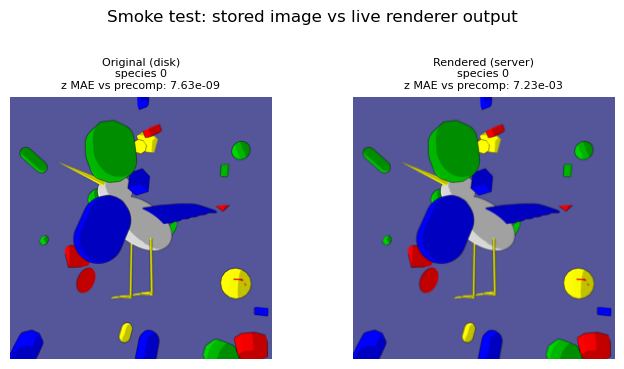

Saved fb_renderer_smoketest_compare.png


In [17]:
# ── Smoke test A: load stored image from disk, verify z matches pre-computed ──
_local_idx = test_idx_by_species[0][0]   # first test image of species 0
_ann       = test_anns[_local_idx]
_class_idx = int(_ann['class_idx'])
_img_path  = FB / 'test' / str(_class_idx) / f'{_local_idx:06d}.png'
_img_disk  = None

if _img_path.exists():
    _img_disk  = Image.open(_img_path).convert('RGB')
    _z_disk, _ = run_through_cbm(_img_disk)
    _gid       = _FUNNYBIRDS_N_TRAIN + _local_idx
    _z_precomp = z_te[id_to_row_te[_gid]]
    _mae_disk  = (_z_disk - _z_precomp).abs().mean().item()
    print(f'Disk image → z MAE vs pre-computed z: {_mae_disk:.6f}  (expected <1e-4)')
else:
    print(f'[skip] Image not on disk: {_img_path}')
    _mae_disk = float('nan')

# ── Smoke test B: render via server ──────────────────────────────────────────
if RENDERER_AVAILABLE:
    _url_example = json_to_url(_ann)
    print(f'\nExample render URL (first 200 chars):\n  {_url_example[:200]}...')

    _img_render = render_ann(_ann)
    _z_render, _p_render = run_through_cbm(_img_render)
    _mae_render = (_z_render - _z_precomp).abs().mean().item() if _img_disk else float('nan')
    print(f'Renderer → z MAE vs pre-computed z: {_mae_render:.6f}  (ideally <0.05)')
    print(f'Renderer top prediction: species {int(_p_render.argmax())}  '
          f'P(species {_class_idx})={_p_render[_class_idx]:.4f}')

    # Pixel difference between disk image and rendered image
    if _img_disk is not None:
        import numpy as np
        _arr_disk   = np.array(_img_disk.resize((256, 256)))
        _arr_render = np.array(_img_render)
        _pixel_mae  = np.abs(_arr_disk.astype(float) - _arr_render.astype(float)).mean()
        print(f'Pixel MAE (disk vs rendered): {_pixel_mae:.2f}  '
              f'(0=identical, <5 is fine, rendering is stochastic in lighting)')

    # ── Display: disk image vs rendered image side by side ──
    ncols = 2 if _img_disk is not None else 1
    fig, axes = plt.subplots(1, ncols, figsize=(ncols * 3.5, 3.5))
    if ncols == 1:
        axes = [axes]
    if _img_disk is not None:
        axes[0].imshow(_img_disk)
        axes[0].set_title(
            f'Original (disk)\nspecies {_class_idx}\n'
            f'z MAE vs precomp: {_mae_disk:.2e}', fontsize=8)
        axes[0].axis('off')
    axes[-1].imshow(_img_render)
    axes[-1].set_title(
        f'Rendered (server)\nspecies {_class_idx}\n'
        f'z MAE vs precomp: {_mae_render:.2e}', fontsize=8)
    axes[-1].axis('off')
    plt.suptitle('Smoke test: stored image vs live renderer output', y=1.04)
    plt.tight_layout()
    plt.savefig('fb_renderer_smoketest_compare.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_renderer_smoketest_compare.png')
else:
    print('[skip] Renderer not available — smoke test B skipped.')
    if _img_disk is not None:
        fig, ax = plt.subplots(figsize=(3.5, 3.5))
        ax.imshow(_img_disk)
        ax.set_title(f'Original (disk) — species {_class_idx}', fontsize=8)
        ax.axis('off')
        plt.tight_layout()
        plt.show()

## 6. Part swap and deletion control helpers

- `swap_part_in_ann(ann, part, new_params)` — returns a copy of `ann` with the
  target part replaced by `new_params` (`{'model': ..., 'color': ...}`).
  Camera, lighting, and background fields are **unchanged** → background preserved.
- `delete_part_in_ann(ann, part)` — sets `{part}_model = ''` (empty = renderer
  treats as absent).  Used for the deletion control ceiling.
- `get_concept_dims(part, var_old, var_new)` — returns `(c_old, c_new)` concept
  indices to track in delta-z.

In [18]:
def swap_part_in_ann(ann: dict, part: str, new_params: dict) -> dict:
    """
    Return a shallow copy of ann with the target part replaced by new_params.
    All camera / lighting / background fields are preserved unchanged.
    """
    cf = dict(ann)                              # shallow copy — all other fields intact
    cf[f'{part}_model'] = new_params['model']
    if part in PARTS_WITH_COLOR:
        cf[f'{part}_color'] = new_params.get('color', '')
    return cf


def delete_part_in_ann(ann: dict, part: str) -> dict:
    """
    Return a copy of ann with the target part removed.
    Empty model string signals the renderer to omit the part entirely
    (same convention as render_interventions.py).
    """
    cf = dict(ann)
    cf[f'{part}_model'] = ''
    if part in PARTS_WITH_COLOR:
        cf[f'{part}_color'] = ''
    return cf


def get_concept_dims(part: str, var_old: int, var_new: int):
    """
    Returns (c_old, c_new): concept vector indices for the old and new variant.
    var_old = species A's original variant index for this part.
    var_new = species B's variant index (the one being swapped in).
    """
    c_old = CONCEPT_TO_IDX.get(f'{part}_{var_old}', -1)
    c_new = CONCEPT_TO_IDX.get(f'{part}_{var_new}', -1)
    return c_old, c_new


print('Defined: swap_part_in_ann  delete_part_in_ann  get_concept_dims')

Defined: swap_part_in_ann  delete_part_in_ann  get_concept_dims


In [19]:
def swap_record_from_ann(
    ann_orig: dict,
    sid_A: int,
    part: str,
    var_old: int,   # A's variant index for this part
    sid_B: int,
    var_new: int,   # B's variant index (being swapped in)
    z_orig: torch.Tensor,    # pre-computed z for this image [26]
) -> dict:
    """
    Render counterfactual (A's params, B's part) through CBM.
    Returns a dict with shift_B, shift_A, delta_z_old, delta_z_new.
    RENDERER_AVAILABLE must be True before calling.
    """
    p_orig   = z_to_probs(z_orig)                            # [50] CPU
    ann_cf   = swap_part_in_ann(ann_orig, part, species_part_params[sid_B][part])
    img_cf   = render_ann(ann_cf)
    z_cf, p_cf = run_through_cbm(img_cf)

    c_old, c_new = get_concept_dims(part, var_old, var_new)

    return {
        'sid_A': sid_A,   'sid_B': sid_B,
        'part': part,
        'var_old': var_old, 'var_new': var_new,
        'shift_B': float(p_cf[sid_B] - p_orig[sid_B]),
        'shift_A': float(p_cf[sid_A] - p_orig[sid_A]),
        'delta_z_old': float(z_cf[c_old] - z_orig[c_old]) if c_old >= 0 else float('nan'),
        'delta_z_new': float(z_cf[c_new] - z_orig[c_new]) if c_new >= 0 else float('nan'),
    }


def deletion_record_from_ann(
    ann_orig: dict,
    sid_A: int,
    part: str,
    z_orig: torch.Tensor,
) -> dict:
    """
    Render deletion counterfactual (part removed entirely).
    drop_A = P_deletion[A] - P_orig[A]  (expected to be negative: losing identity).
    |drop_A| is the ceiling: maximum loss from removing the part entirely.
    """
    p_orig   = z_to_probs(z_orig)
    ann_del  = delete_part_in_ann(ann_orig, part)
    img_del  = render_ann(ann_del)
    _, p_del = run_through_cbm(img_del)

    return {
        'sid_A': sid_A,
        'part': part,
        'drop_A': float(p_del[sid_A] - p_orig[sid_A]),
    }


print('Defined: swap_record_from_ann  deletion_record_from_ann')

Defined: swap_record_from_ann  deletion_record_from_ann


[renderer] crash detected, restarting (attempt 1)...


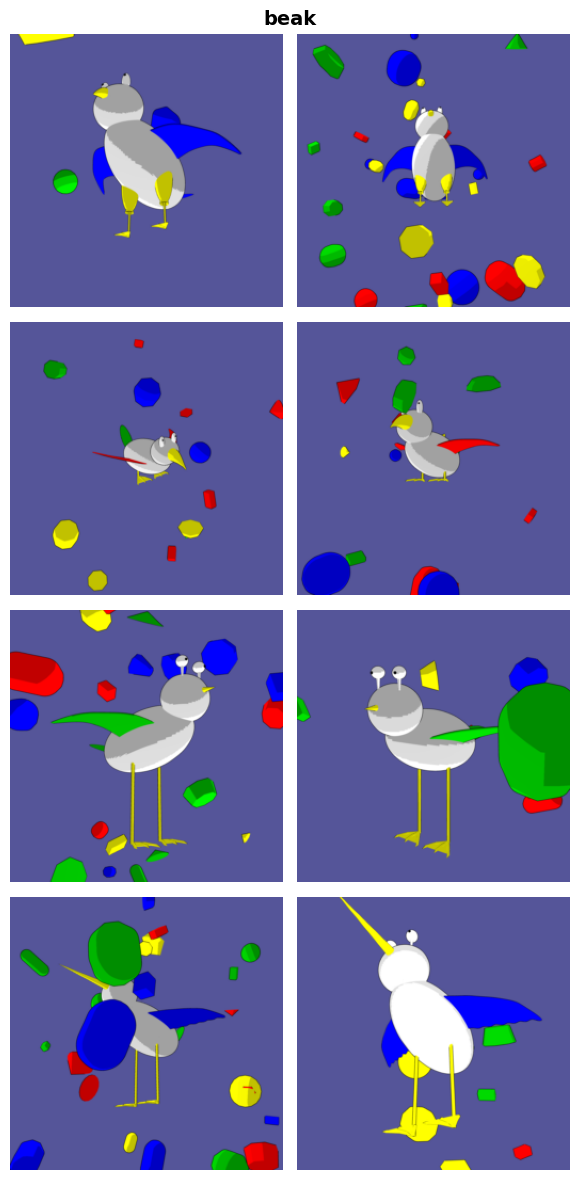

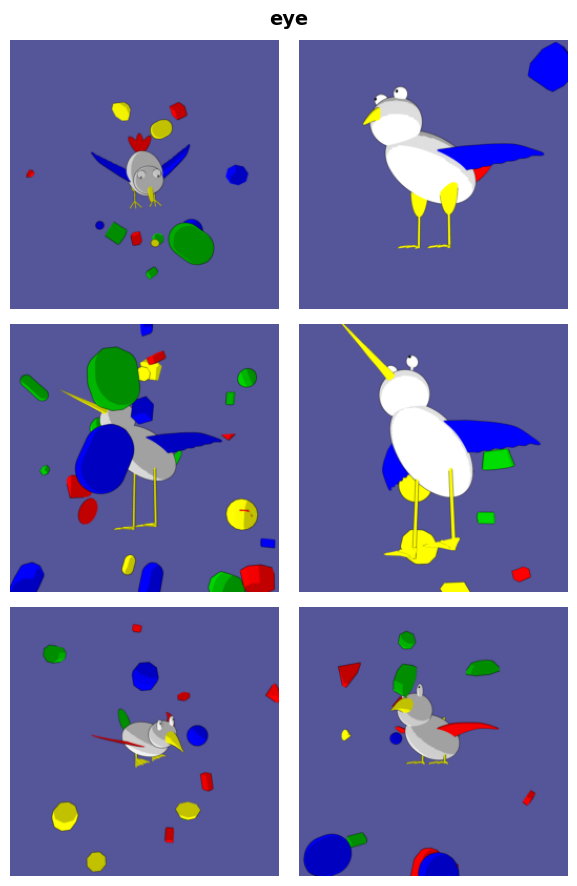

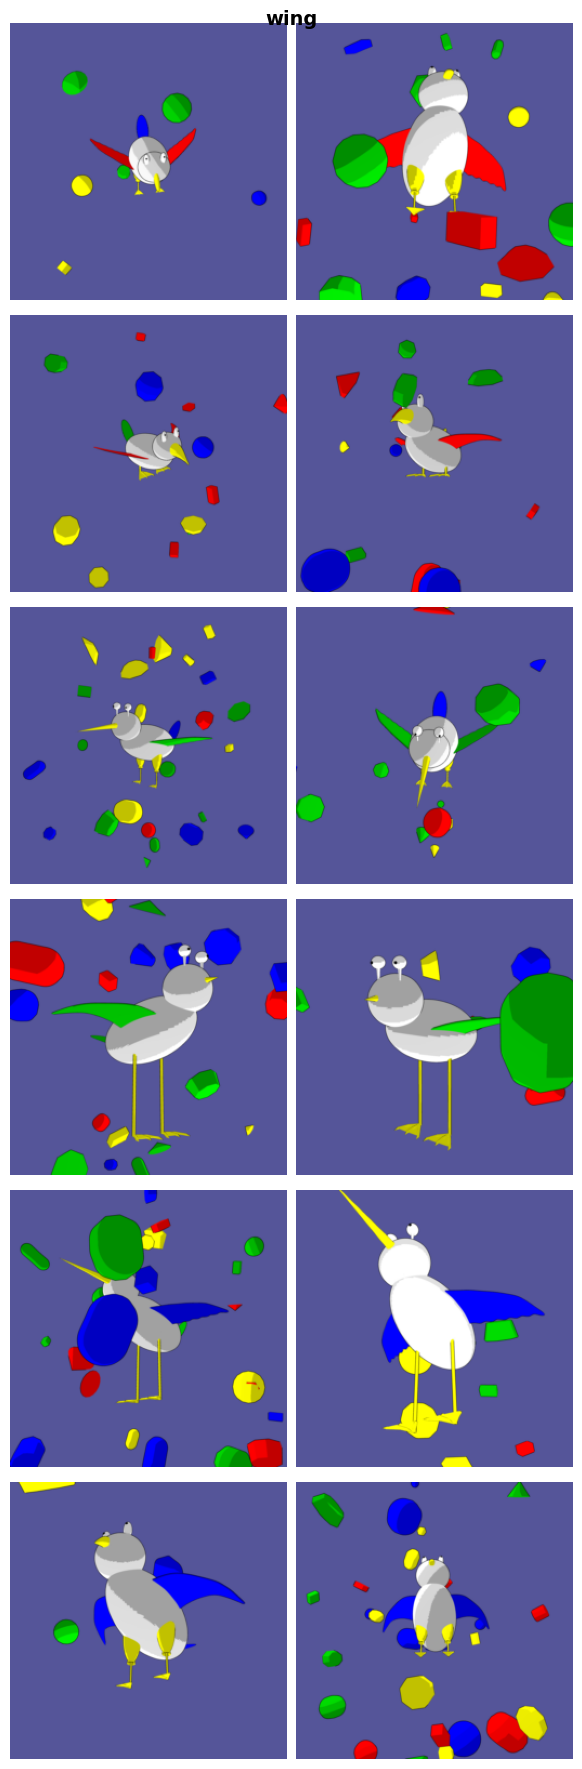

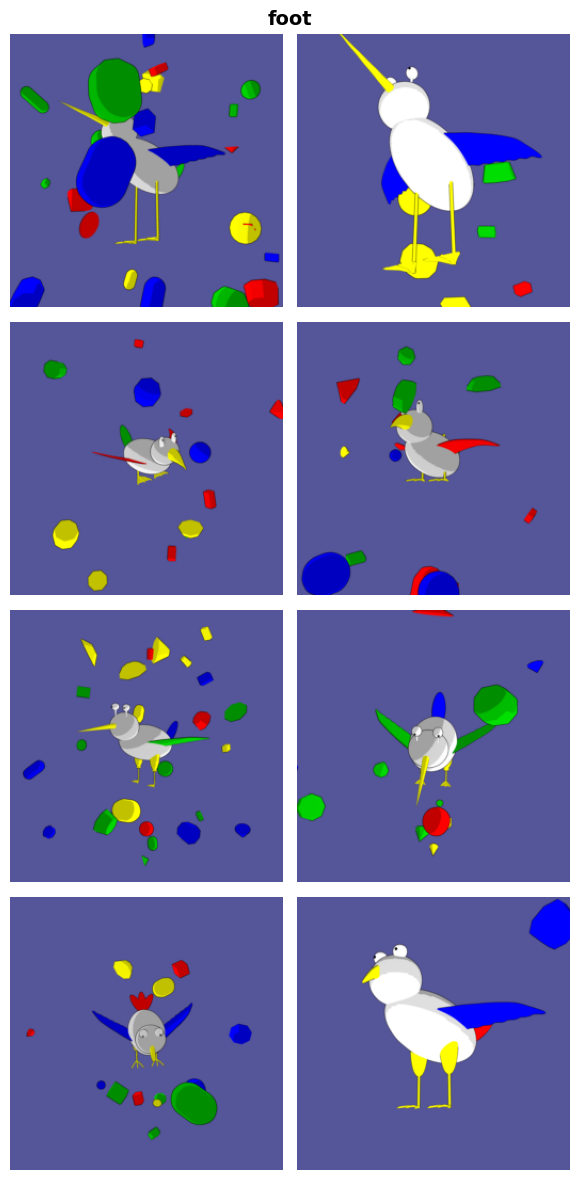

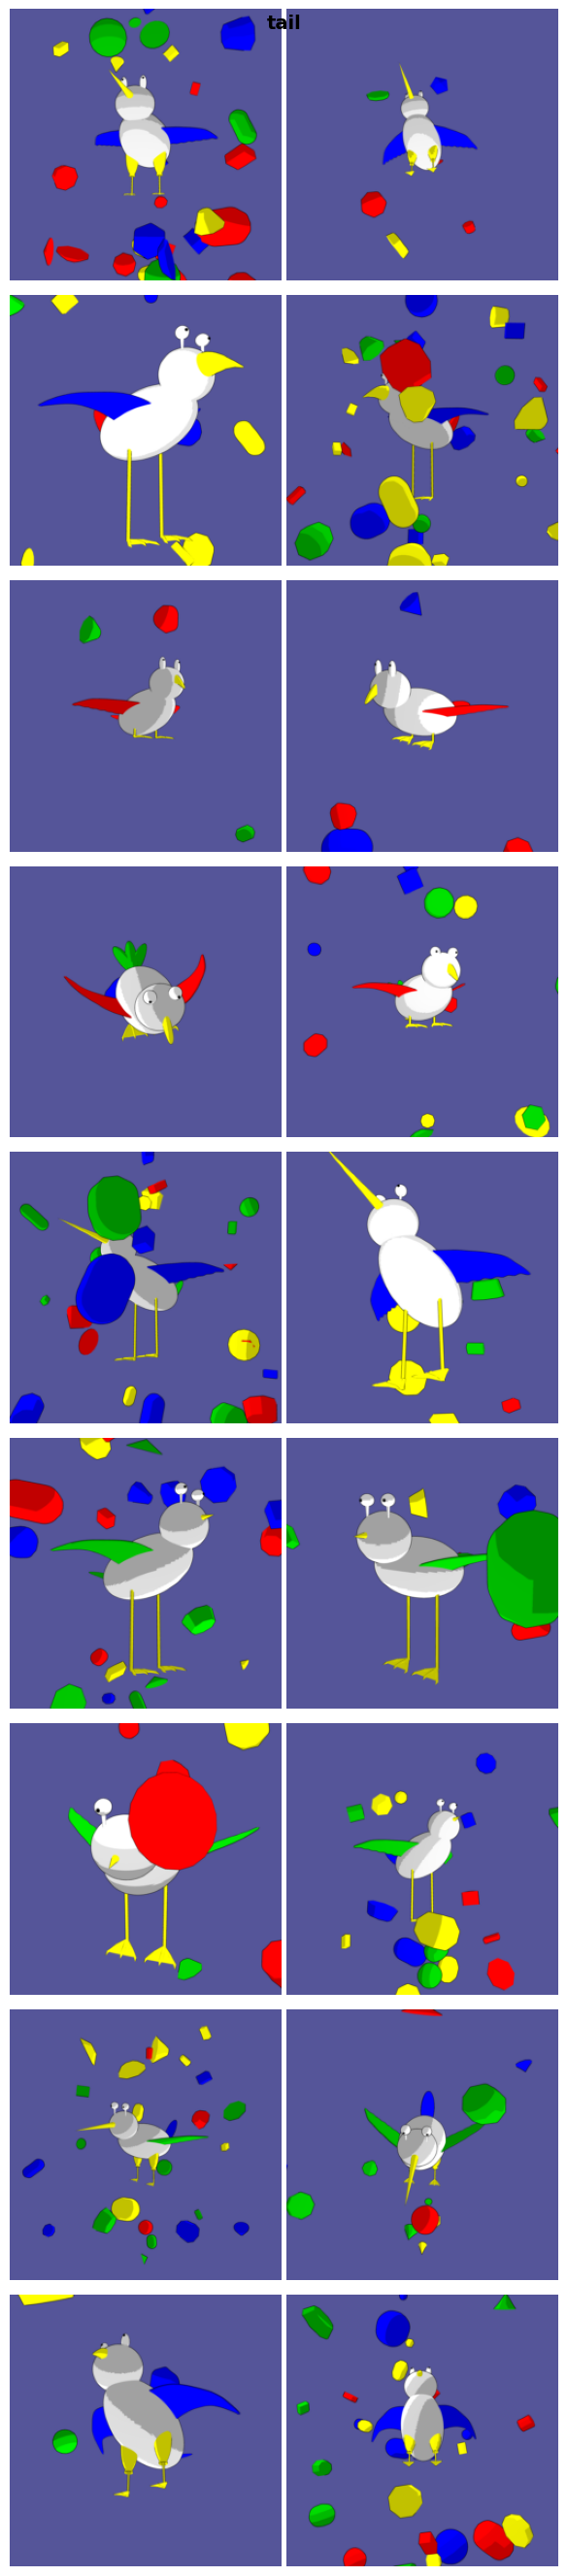

In [105]:
# ── Tuneable: bump to swap out occluded images ────────────────────────────────
# SAMPLE_OFFSET['tail'][3] = 2  →  skip first 2 images for tail variant 3
SAMPLE_OFFSET = {
    # 'beak': {1: 1},
}

def _variant_sample(part, variant, offset):
    candidates = [
        (sid, local_idx)
        for sid in range(N_SPECIES)
        if species_variant_idx[sid][part] == variant
        for local_idx in test_idx_by_species[sid][:MAX_IMGS_PER_SPECIES]
    ]
    if not candidates:
        return None
    sid, local_idx = candidates[offset % len(candidates)]
    return test_anns[local_idx]

N_COLS = 2

for part in PARTS:
    variants = sorted({species_variant_idx[sid][part] for sid in range(N_SPECIES)})
    part_offsets = SAMPLE_OFFSET.get(part, {})

    fig, axes = plt.subplots(len(variants), N_COLS,
                             figsize=(N_COLS * 3, len(variants) * 3),
                             squeeze=False)
    fig.suptitle(f'{part}', fontsize=14, fontweight='bold')

    for row, v in enumerate(variants):
        base_offset = part_offsets.get(v, 0)
        for col in range(N_COLS):
            ann = _variant_sample(part, v, base_offset + col)
            ax = axes[row][col]
            if ann is None:
                ax.axis('off')
                continue
            ax.imshow(render_ann(ann))
            ax.axis('off')
            if col == 0:
                ax.set_ylabel(f'variant {v}', fontsize=9)
                ax.yaxis.set_visible(True)
                ax.tick_params(left=False, labelleft=True)

    plt.tight_layout()
    plt.savefig(f'part_grid_{part}.png', dpi=120, bbox_inches='tight')
    plt.show()

### Renderer visual check — per-part swap and deletion grid

Renders a single base image three ways for each body part:
- **Original** — same parameters as the stored test image
- **Swap** — one part replaced by a donor species' variant
- **Deletion** — that part entirely removed (blank model string)

**What to look for:** only the target part should change between columns.
Camera angle, lighting, background, and all other parts must be identical.

Base species: 0 (funnybird_00)
Donor per part: beak→sp2, eye→sp2, wing→sp1, foot→sp1, tail→sp1
Parts: ['beak', 'eye', 'wing', 'foot', 'tail']
Part variants for base species: beak=3, eye=1, wing=4, foot=0, tail=4
donendering beak ... 
donendering eye ... 
donendering wing ... 
donendering foot ... 
donendering tail ... 
  beak swap  → ΔP(A)=-0.0018  ΔP(B)=+0.0000
  beak delete → ΔP(A)=-0.0030  (ceiling)
  eye swap  → ΔP(A)=+0.0000  ΔP(B)=+0.0000
  eye delete → ΔP(A)=+0.0000  (ceiling)
  wing swap  → ΔP(A)=-0.9192  ΔP(B)=+0.0071
  wing delete → ΔP(A)=-0.1398  (ceiling)
  foot swap  → ΔP(A)=-0.9507  ΔP(B)=+0.0134
  foot delete → ΔP(A)=-0.0075  (ceiling)
  tail swap  → ΔP(A)=-0.0044  ΔP(B)=+0.0001
  tail delete → ΔP(A)=-0.3689  (ceiling)


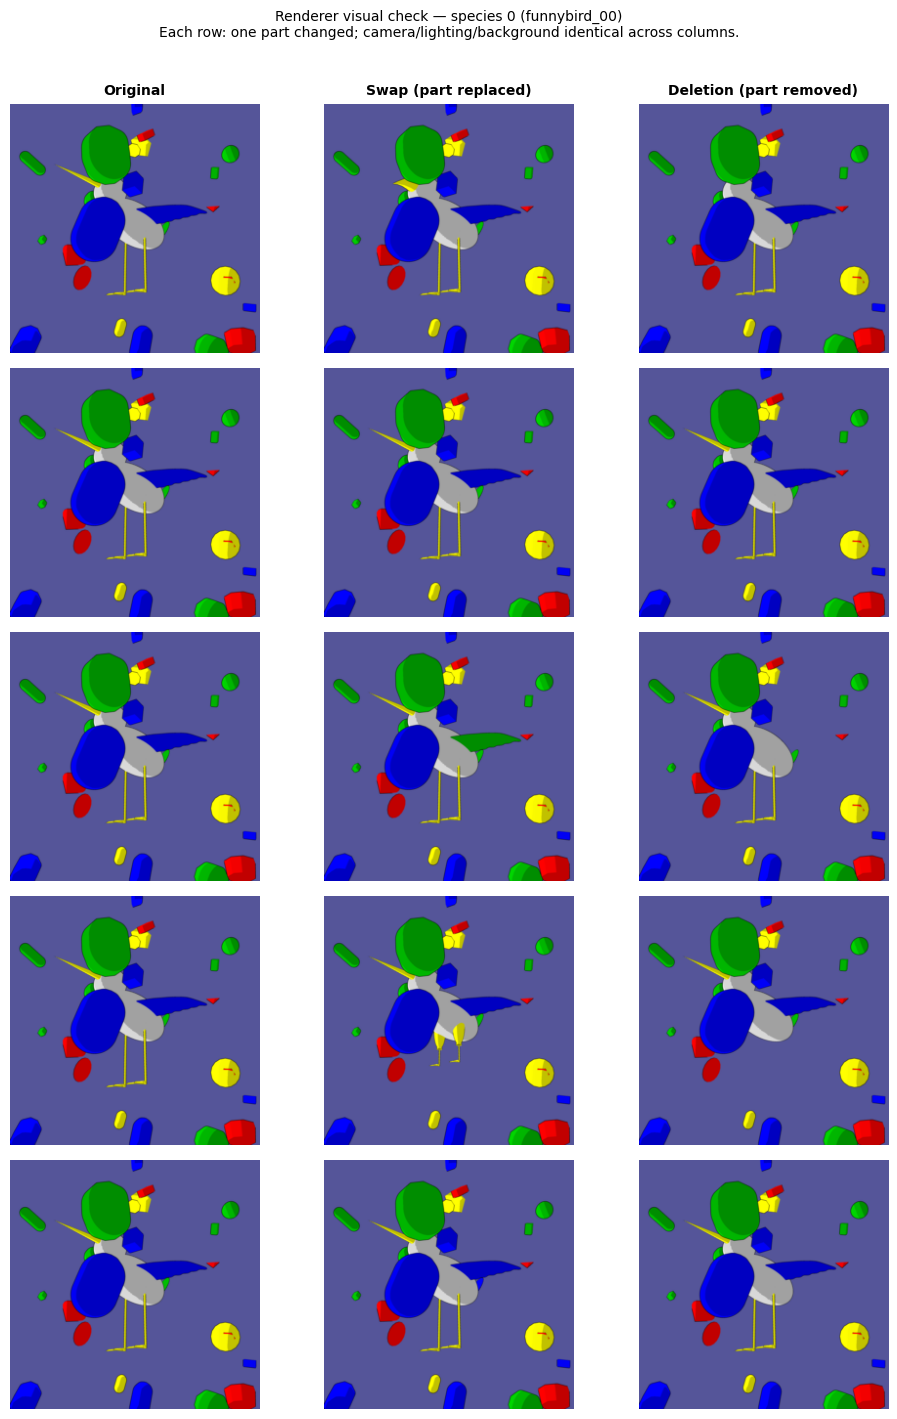


Saved fb_renderer_visual_grid.png
Visual check complete. Verify:
  [1] Only the target part changes between columns (background/camera identical)
  [2] Deletion column is missing that part entirely
  [3] ΔP(A) < 0 after deletion of any part (prediction hurt)
  [4] ΔP(B) > 0 after swap toward B (leakage signal)


In [20]:
if not RENDERER_AVAILABLE:
    print('[skip] Renderer not available — start Node.js server and re-run.')
else:
    _vsid      = 0   # base species for visual check (change freely)
    _v_idx     = test_idx_by_species[_vsid][0]
    _v_ann     = test_anns[_v_idx]
    _v_gid     = _FUNNYBIRDS_N_TRAIN + _v_idx
    _v_z_orig, _v_p_orig = run_through_cbm(render_ann(_v_ann))

    # Find one donor species per part (different variant, first available)
    _donors = {}
    for _part in PARTS:
        _var_A = species_variant_idx[_vsid][_part]
        for _sid_B in range(N_SPECIES):
            if _sid_B != _vsid and species_variant_idx[_sid_B][_part] != _var_A:
                _donors[_part] = _sid_B
                break

    print(f'Base species: {_vsid} ({spname(_vsid)})')
    print(f'Donor per part: ' + ', '.join(f'{p}→sp{d}' for p, d in _donors.items()))
    print(f'Parts: {PARTS}')
    print(f'Part variants for base species: '
          + ', '.join(f'{p}={species_variant_idx[_vsid][p]}' for p in PARTS))

    # ── Render all images (3 per part = 15 total) ───────────────────────────
    _grid = {}  # part → {'orig': img, 'swap': (img, donor_sid), 'del': img}
    for _part in PARTS:
        print(f'  Rendering {_part} ...', end=' ', flush=True)
        _donor = _donors.get(_part)
        _orig  = render_ann(_v_ann)

        _ann_sw = swap_part_in_ann(_v_ann, _part,
                                   species_part_params[_donor][_part]) if _donor else None
        _img_sw = render_ann(_ann_sw) if _ann_sw else None

        _ann_dl = delete_part_in_ann(_v_ann, _part)
        _img_dl = render_ann(_ann_dl)

        _grid[_part] = {'orig': _orig, 'swap': (_img_sw, _donor), 'del': _img_dl}
        print('done')

    # ── Display grid: rows = parts, cols = [original | swap | deletion] ─────
    _nrows = len(PARTS)
    fig, axes = plt.subplots(_nrows, 3, figsize=(10, _nrows * 2.8))
    _col_titles = ['Original', 'Swap (part replaced)', 'Deletion (part removed)']
    for ci, ct in enumerate(_col_titles):
        axes[0, ci].set_title(ct, fontsize=10, fontweight='bold', pad=6)

    for ri, _part in enumerate(PARTS):
        _g      = _grid[_part]
        _color  = PART_COLORS[_part]

        # Left label: part name
        axes[ri, 0].set_ylabel(_part, fontsize=10, rotation=0,
                               ha='right', labelpad=40, color=_color, fontweight='bold')

        # Col 0 — original (same for every row, but rendered fresh to confirm consistency)
        axes[ri, 0].imshow(_g['orig'])
        _pred_orig = int(_v_p_orig.argmax())
        axes[ri, 0].set_xlabel(
            f'pred={_pred_orig} P({_vsid})={_v_p_orig[_vsid]:.3f}', fontsize=7)

        # Col 1 — swap
        _img_sw, _donor = _g['swap']
        if _img_sw is not None:
            axes[ri, 1].imshow(_img_sw)
            _, _p_sw = run_through_cbm(_img_sw)
            _dpA = float(_p_sw[_vsid]   - _v_p_orig[_vsid])
            _dpB = float(_p_sw[_donor]  - _v_p_orig[_donor])
            axes[ri, 1].set_xlabel(
                f'donor=sp{_donor}  ΔP(A)={_dpA:+.3f}  ΔP(B)={_dpB:+.3f}', fontsize=7)
            print(f'  {_part} swap  → ΔP(A)={_dpA:+.4f}  ΔP(B)={_dpB:+.4f}')
        else:
            axes[ri, 1].text(0.5, 0.5, 'no donor', ha='center', va='center',
                             transform=axes[ri, 1].transAxes)

        # Col 2 — deletion
        axes[ri, 2].imshow(_g['del'])
        _, _p_dl = run_through_cbm(_g['del'])
        _dpA_dl = float(_p_dl[_vsid] - _v_p_orig[_vsid])
        axes[ri, 2].set_xlabel(f'ΔP(A)={_dpA_dl:+.3f}  (deletion ceiling)', fontsize=7)
        print(f'  {_part} delete → ΔP(A)={_dpA_dl:+.4f}  (ceiling)')

        for ci in range(3):
            axes[ri, ci].axis('off')
            for spine in axes[ri, ci].spines.values():
                spine.set_edgecolor(_color)
                spine.set_linewidth(1.5)

    plt.suptitle(
        f'Renderer visual check — species {_vsid} ({spname(_vsid)})\n'
        f'Each row: one part changed; camera/lighting/background identical across columns.',
        y=1.01, fontsize=10)
    plt.tight_layout()
    plt.savefig('fb_renderer_visual_grid.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\nSaved fb_renderer_visual_grid.png')
    print('Visual check complete. Verify:')
    print('  [1] Only the target part changes between columns (background/camera identical)')
    print('  [2] Deletion column is missing that part entirely')
    print('  [3] ΔP(A) < 0 after deletion of any part (prediction hurt)')
    print('  [4] ΔP(B) > 0 after swap toward B (leakage signal)')

## 7. Z-ordering experiment — visual grounding test

**The question:** after showing the model an image with species B's tail variant,
does the concept bottleneck correctly identify the new part?

```
z[tail_B_dim] > z[tail_A_dim]  ?
```

On FunnyBirds, parts are visually unambiguous, so this ordering should **always** hold
(null: 100% correct).  Any violation means the bottleneck is anchored to species-A
identity rather than the visual content of the image.

**Metrics per image:**
- `margin = z_cf[c_donor] − z_cf[c_src]`  (positive = correct, negative = violation)
- `ordering_correct = margin > 0`

**GT intervention ceiling:**  
Surgically set `z_orig[c_donor] = 1`, `z_orig[c_src] = 0`, run label head → P_gt[donor].  
This is what a *perfectly grounded* bottleneck would predict after the swap.

**Leakage score** = `P_gt[donor] − P_render[donor]`  
How much visual evidence the bottleneck failed to recover.  
Should be ≈ 0 on FunnyBirds if the bottleneck is doing its job.

In [21]:
def z_ordering_record(
    ann_orig: dict,
    sid_src: int,
    part: str,
    var_src: int,
    sid_donor: int,
    var_donor: int,
    z_orig: torch.Tensor,
) -> dict:
    """
    Render source image with donor species' part variant.
    Check: z_cf[c_donor] > z_cf[c_src]?
    GT ceiling: set z_orig[c_donor]=1, z_orig[c_src]=0, run label head.
    For tail swaps also stores all 9 tail z-values for confusion analysis.
    """
    c_src   = CONCEPT_TO_IDX[f'{part}_{var_src}']
    c_donor = CONCEPT_TO_IDX[f'{part}_{var_donor}']

    ann_cf       = swap_part_in_ann(ann_orig, part, species_part_params[sid_donor][part])
    img_cf       = render_ann(ann_cf)
    z_cf, p_cf   = run_through_cbm(img_cf)

    z_new  = float(z_cf[c_donor])
    z_old  = float(z_cf[c_src])
    margin = z_new - z_old

    z_gt          = z_orig.clone()
    z_gt[c_donor] = 1.0
    z_gt[c_src]   = 0.0
    p_gt          = z_to_probs(z_gt)

    row = {
        'sid_src':          sid_src,
        'sid_donor':        sid_donor,
        'part':             part,
        'var_src':          var_src,
        'var_donor':        var_donor,
        'c_src':            c_src,
        'c_donor':          c_donor,
        'z_new':            z_new,
        'z_old':            z_old,
        'z_new_orig':       float(z_orig[c_donor]),
        'z_old_orig':       float(z_orig[c_src]),
        'margin':           margin,
        'ordering_correct': bool(margin > 0),
        'p_cf_donor':       float(p_cf[sid_donor]),
        'p_gt_donor':       float(p_gt[sid_donor]),
    }
    # All tail concept z-values for confusion matrix analysis
    if part == 'tail':
        for i in range(PART_VARIANTS['tail']):
            row[f'z_cf_tail_{i}'] = float(z_cf[CONCEPT_TO_IDX[f'tail_{i}']])
    return row

print('Defined: z_ordering_record')


Defined: z_ordering_record


### 7a. Tail (primary experiment)

In [22]:
tail_z_pairs = [
    (sid_A, species_variant_idx[sid_A]['tail'],
     sid_B, species_variant_idx[sid_B]['tail'])
    for sid_A, sid_B in combinations(range(N_SPECIES), 2)
    if species_variant_idx[sid_A]['tail'] != species_variant_idx[sid_B]['tail']
]

if MAX_PAIRS_PER_PART is not None and len(tail_z_pairs) > MAX_PAIRS_PER_PART:
    _run_z_tail = random.Random(42).sample(tail_z_pairs, MAX_PAIRS_PER_PART)
else:
    _run_z_tail = tail_z_pairs

_n_renders = len(_run_z_tail) * 2 * MAX_IMGS_PER_SPECIES
print(f'Tail z-ordering pairs: {len(tail_z_pairs)}  running: {len(_run_z_tail)}')
print(f'Estimated renders: {_n_renders}  (~{_n_renders * 1.5 / 60:.0f} min at 1.5 s each)')

Tail z-ordering pairs: 1094  running: 100
Estimated renders: 1000  (~25 min at 1.5 s each)


In [23]:
import subprocess, time

# Diagnose first
import subprocess
print("Kernel host:", subprocess.run(['hostname'], capture_output=True, text=True).stdout.strip())
print("node binary:", subprocess.run(['which', 'node'], capture_output=True, text=True).stdout.strip())
print("RENDERER_DIR exists:", RENDERER_DIR.exists())

Kernel host: adroit-h11n4
node binary: /home/cr7998/.conda/envs/cubvision-gpu/bin/node
RENDERER_DIR exists: True


In [24]:
tail_z_rows = []

if not RENDERER_AVAILABLE:
    print('[SKIP] Renderer not available.')
else:
    for sid_A, var_A, sid_B, var_B in tqdm(_run_z_tail, desc='tail z-ordering'):
        # Forward: A images with B's tail
        for local_idx in test_idx_by_species[sid_A][:MAX_IMGS_PER_SPECIES]:
            gid = _FUNNYBIRDS_N_TRAIN + local_idx
            row = id_to_row_te.get(gid)
            if row is None: continue
            r = z_ordering_record(
                test_anns[local_idx], sid_A, 'tail', var_A, sid_B, var_B, z_te[row])
            r['direction'] = 'fwd'
            tail_z_rows.append(r)

        # Backward: B images with A's tail
        for local_idx in test_idx_by_species[sid_B][:MAX_IMGS_PER_SPECIES]:
            gid = _FUNNYBIRDS_N_TRAIN + local_idx
            row = id_to_row_te.get(gid)
            if row is None: continue
            r = z_ordering_record(
                test_anns[local_idx], sid_B, 'tail', var_B, sid_A, var_A, z_te[row])
            r['direction'] = 'bwd'
            tail_z_rows.append(r)

    print(f'Tail z-ordering rows: {len(tail_z_rows)}')

tail z-ordering:   0%|          | 0/100 [00:00<?, ?it/s]

Tail z-ordering rows: 1000
  ordering_correct: 47.600%  (null = 100%, any violation = leakage)
  mean margin:      +0.0582


KeyError: 'leakage'

In [27]:
if tail_z_rows:
    _df = pd.DataFrame(tail_z_rows)
    print(f'Tail z-ordering rows: {len(tail_z_rows)}')
    print(f'  ordering_correct: {_df["ordering_correct"].mean():.3%}  '
          f'(null = 100%, any violation = backwash)')
    print(f'  mean margin:      {_df["margin"].mean():+.4f}')

Tail z-ordering rows: 1000
  ordering_correct: 47.600%  (null = 100%, any violation = backwash)
  mean margin:      +0.0582


### 7b. Extend to all body parts

In [43]:
all_z_rows = list(tail_z_rows)  # starts with tail

if not RENDERER_AVAILABLE:
    print('[SKIP] Renderer not available.')
else:
    for part in [p for p in PARTS if p != 'tail']:
        _pairs = [
            (sid_A, species_variant_idx[sid_A][part],
             sid_B, species_variant_idx[sid_B][part])
            for sid_A, sid_B in combinations(range(N_SPECIES), 2)
            if species_variant_idx[sid_A][part] != species_variant_idx[sid_B][part]
        ]
        if MAX_PAIRS_PER_PART is not None and len(_pairs) > MAX_PAIRS_PER_PART:
            _pairs = random.Random(42).sample(_pairs, MAX_PAIRS_PER_PART)
        print(f'{part}: {len(_pairs)} pairs')

        for sid_A, var_A, sid_B, var_B in tqdm(_pairs, desc=part):
            for local_idx in test_idx_by_species[sid_A][:MAX_IMGS_PER_SPECIES]:
                gid = _FUNNYBIRDS_N_TRAIN + local_idx
                row = id_to_row_te.get(gid)
                if row is None: continue
                r = z_ordering_record(
                    test_anns[local_idx], sid_A, part, var_A, sid_B, var_B, z_te[row])
                r['direction'] = 'fwd'
                all_z_rows.append(r)

            for local_idx in test_idx_by_species[sid_B][:MAX_IMGS_PER_SPECIES]:
                gid = _FUNNYBIRDS_N_TRAIN + local_idx
                row = id_to_row_te.get(gid)
                if row is None: continue
                r = z_ordering_record(
                    test_anns[local_idx], sid_B, part, var_B, sid_A, var_A, z_te[row])
                r['direction'] = 'bwd'
                all_z_rows.append(r)

        _part_df = pd.DataFrame([r for r in all_z_rows if r['part'] == part])
        print(f'  ordering_correct: {_part_df["ordering_correct"].mean():.3%}  '
              f'mean margin: {_part_df["margin"].mean():+.4f}')

beak: 100 pairs


beak:   0%|          | 0/100 [00:00<?, ?it/s]

[renderer] crash detected, restarting (attempt 1)...
  ordering_correct: 76.200%  mean margin: +0.4826
eye: 100 pairs


eye:   0%|          | 0/100 [00:00<?, ?it/s]

  ordering_correct: 87.100%  mean margin: +0.7210
wing: 100 pairs


wing:   0%|          | 0/100 [00:00<?, ?it/s]

  ordering_correct: 96.600%  mean margin: +0.8411
foot: 100 pairs


foot:   0%|          | 0/100 [00:00<?, ?it/s]

  ordering_correct: 96.600%  mean margin: +0.8836


In [44]:
if all_z_rows:
    z_order_df = pd.DataFrame(all_z_rows)
    z_order_df.to_csv('fb_cbm_z_ordering.csv', index=False)
    print(f'Saved fb_cbm_z_ordering.csv  ({len(z_order_df)} rows)')

    part_summary = (
        z_order_df.groupby('part', as_index=False)
        .agg(
            n_images        = ('ordering_correct', 'size'),
            frac_correct    = ('ordering_correct', 'mean'),
            mean_margin     = ('margin', 'mean'),
            std_margin      = ('margin', 'std'),
            frac_violations = ('ordering_correct', lambda x: 1 - x.mean()),
            mean_p_cf_donor = ('p_cf_donor', 'mean'),
            # classifier weight proxy: how strongly label head uses this concept
            # NOT an intervention ceiling — do not interpret as upper bound on render swap
            mean_p_gt_donor = ('p_gt_donor', 'mean'),
        )
        .sort_values('frac_violations', ascending=False)
        .reset_index(drop=True)
    )
    print('\nAggregate results (sorted by violation rate):')
    print('  mean_p_gt_donor = classifier weight proxy, NOT a ceiling')
    display(part_summary)

Saved fb_cbm_z_ordering.csv  (5000 rows)

Aggregate results (sorted by violation rate):
  mean_p_gt_donor = classifier weight proxy, NOT a ceiling


,part,n_images,frac_correct,mean_margin,std_margin,frac_violations,mean_p_cf_donor,mean_p_gt_donor
0,tail,1000,0.476,0.058219,0.688729,0.524,0.019108,0.031525
1,beak,1000,0.762,0.482622,0.599867,0.238,0.025227,0.023569
2,eye,1000,0.871,0.720976,0.507817,0.129,0.040753,0.038881
3,foot,1000,0.966,0.883631,0.309973,0.034,0.056208,0.043076
4,wing,1000,0.966,0.841114,0.332220,0.034,0.054828,0.027602


In [45]:
if all_z_rows:
    overall = z_order_df['ordering_correct'].mean()
    n_total = len(z_order_df)
    n_viol  = int((~z_order_df['ordering_correct']).sum())
    worst   = part_summary.iloc[0]
    best    = part_summary.iloc[-1]
    print('=' * 55)
    print(f'  HEADLINE: z-ordering correct {overall:.1%} ({n_total - n_viol}/{n_total})')
    print(f'  Violations: {n_viol} / {n_total} ({1-overall:.1%})')
    print(f'  Most violated part : {worst["part"]} ({worst["frac_violations"]:.1%} violations)')
    print(f'  Best grounded part : {best["part"]}  ({best["frac_violations"]:.1%} violations)')
    print('=' * 55)


  HEADLINE: z-ordering correct 80.8% (4041/5000)
  Violations: 959 / 5000 (19.2%)
  Most violated part : tail (52.4% violations)
  Best grounded part : wing  (3.4% violations)


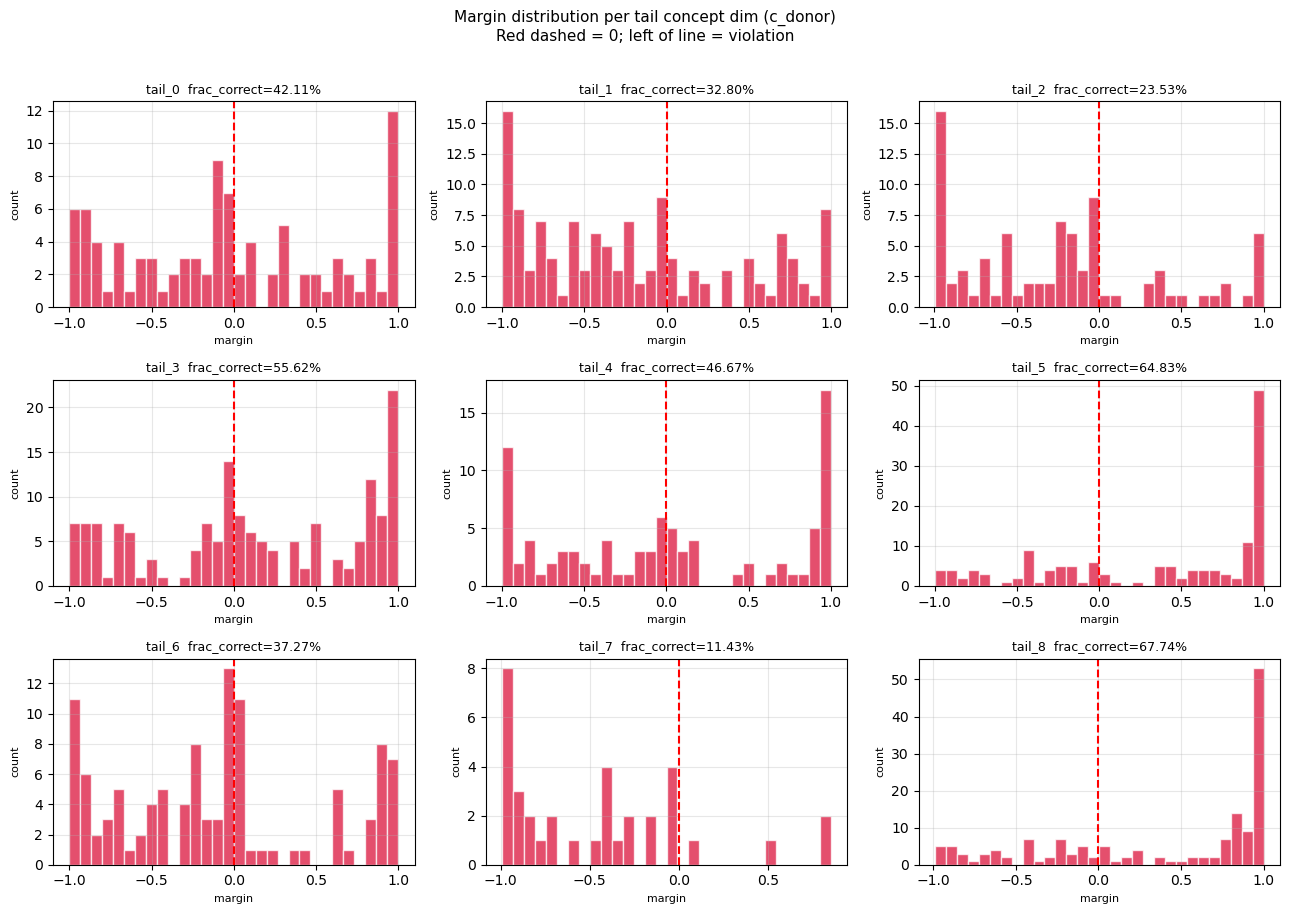

Saved fb_z_tail_concept_margins.png


In [46]:
if all_z_rows:
    tail_df   = z_order_df[z_order_df['part'] == 'tail'].copy()
    n_tail    = PART_VARIANTS['tail']
    fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharey=False)
    axes      = axes.flatten()

    for i in range(n_tail):
        ax   = axes[i]
        cidx = CONCEPT_TO_IDX[f'tail_{i}']
        sub  = tail_df[tail_df['c_donor'] == cidx]
        if sub.empty:
            ax.set_visible(False); continue
        fc = sub['ordering_correct'].mean()
        ax.hist(sub['margin'], bins=30, color=PART_COLORS['tail'], alpha=0.75, edgecolor='white')
        ax.axvline(0, color='red', ls='--', lw=1.5)
        ax.set_title(f'tail_{i}  frac_correct={fc:.2%}', fontsize=9)
        ax.set_xlabel('margin', fontsize=8)
        ax.set_ylabel('count', fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Margin distribution per tail concept dim (c_donor)\n'
                 'Red dashed = 0; left of line = violation', y=1.01, fontsize=11)
    plt.tight_layout()
    plt.savefig('fb_z_tail_concept_margins.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_z_tail_concept_margins.png')


## Concept grounding before any swap

`z_old_orig` = model activation of the **source** concept in the original image (should be high — part is present).

`z_new_orig` = model activation of the **donor** concept in the original image (should be ~0 — part is absent).

High `z_new_orig` before the swap is a direct signature of backwash: the model already partially activates the donor concept without seeing that part.

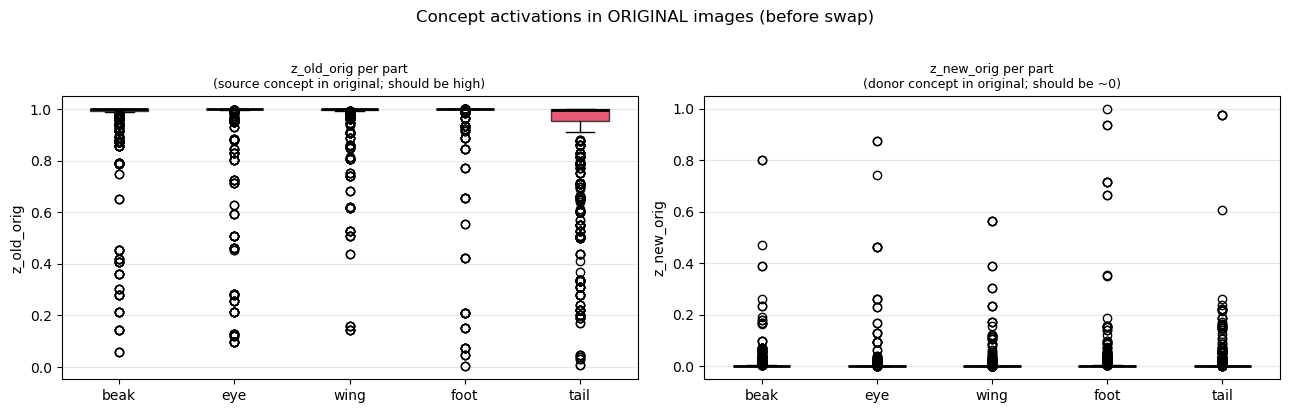

Saved fb_z_grounding_boxplots.png


In [47]:
if all_z_rows:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ax, col, title in [
        (axes[0], 'z_old_orig', 'z_old_orig per part\n(source concept in original; should be high)'),
        (axes[1], 'z_new_orig', 'z_new_orig per part\n(donor concept in original; should be ~0)'),
    ]:
        data = [z_order_df[z_order_df['part'] == p][col].values for p in PARTS]
        bp   = ax.boxplot(data, patch_artist=True, medianprops=dict(color='black', lw=2))
        for patch, part in zip(bp['boxes'], PARTS):
            patch.set_facecolor(PART_COLORS[part]); patch.set_alpha(0.7)
        ax.set_xticks(range(1, len(PARTS)+1))
        ax.set_xticklabels(PARTS)
        ax.set_ylabel(col)
        ax.set_title(title, fontsize=9)
        ax.grid(True, axis='y', alpha=0.3)

    plt.suptitle('Concept activations in ORIGINAL images (before swap)', y=1.02)
    plt.tight_layout()
    plt.savefig('fb_z_grounding_boxplots.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_z_grounding_boxplots.png')


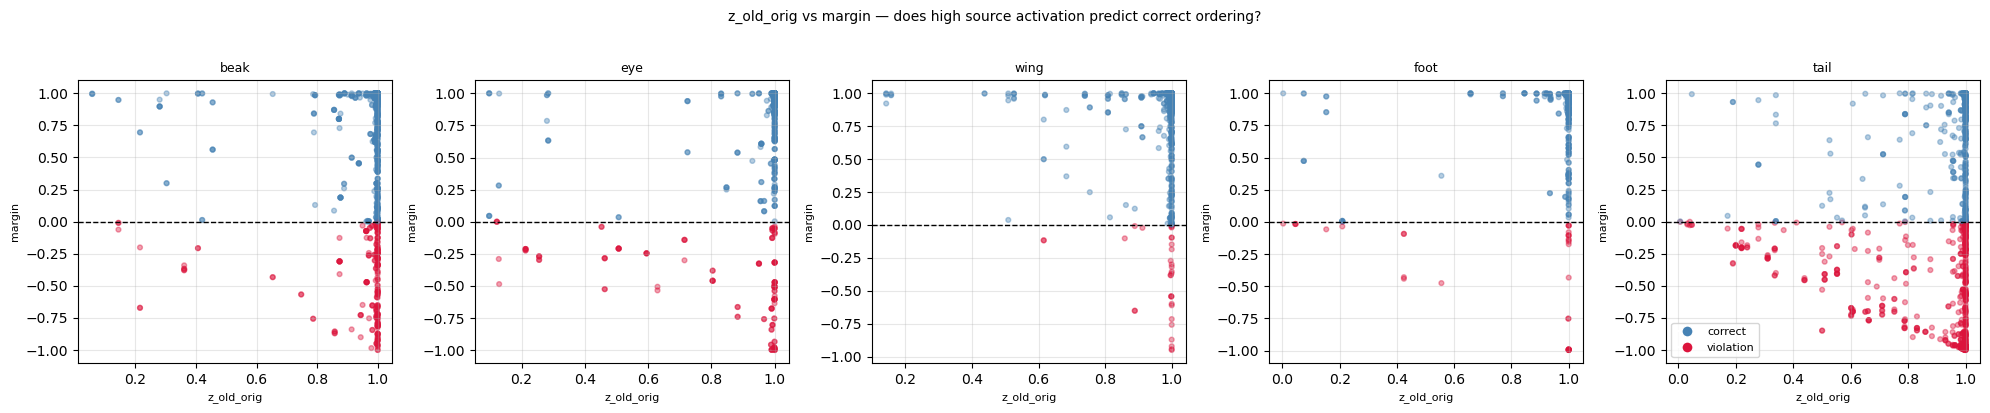

Saved fb_z_old_orig_vs_margin.png


In [48]:
if all_z_rows:
    from matplotlib.lines import Line2D
    fig, axes = plt.subplots(1, len(PARTS), figsize=(4 * len(PARTS), 4))
    for ax, part in zip(axes, PARTS):
        sub    = z_order_df[z_order_df['part'] == part]
        colors = sub['ordering_correct'].map({True: 'steelblue', False: 'crimson'})
        ax.scatter(sub['z_old_orig'], sub['margin'], c=colors, s=12, alpha=0.4)
        ax.axhline(0, color='black', ls='--', lw=1)
        ax.set_xlabel('z_old_orig', fontsize=8)
        ax.set_ylabel('margin', fontsize=8)
        ax.set_title(part, fontsize=9)
        ax.grid(True, alpha=0.3)

    axes[-1].legend(handles=[
        Line2D([0],[0],marker='o',color='w',markerfacecolor='steelblue',ms=8,label='correct'),
        Line2D([0],[0],marker='o',color='w',markerfacecolor='crimson', ms=8,label='violation'),
    ], fontsize=8)
    plt.suptitle('z_old_orig vs margin — does high source activation predict correct ordering?',
                 y=1.02, fontsize=10)
    plt.tight_layout()
    plt.savefig('fb_z_old_orig_vs_margin.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_z_old_orig_vs_margin.png')


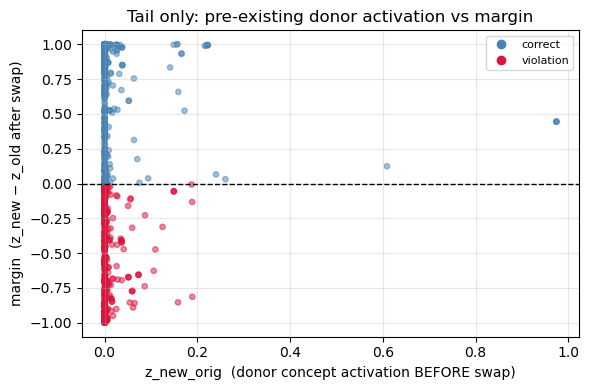

Saved fb_z_new_orig_vs_margin_tail.png


In [65]:
if all_z_rows:
    from matplotlib.lines import Line2D
    tail_df = z_order_df[z_order_df['part'] == 'tail']
    colors  = tail_df['ordering_correct'].map({True: 'steelblue', False: 'crimson'})
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(tail_df['z_new_orig'], tail_df['margin'], c=colors, s=15, alpha=0.5)
    ax.axhline(0, color='black', ls='--', lw=1)
    ax.set_xlabel('z_new_orig  (donor concept activation BEFORE swap)')
    ax.set_ylabel('margin  (z_new − z_old after swap)')
    ax.set_title('Tail only: pre-existing donor activation vs margin')
    ax.grid(True, alpha=0.3)
    ax.legend(handles=[
        Line2D([0],[0],marker='o',color='w',markerfacecolor='steelblue',ms=8,label='correct'),
        Line2D([0],[0],marker='o',color='w',markerfacecolor='crimson', ms=8,label='violation'),
    ], fontsize=8)
    plt.tight_layout()
    plt.savefig('fb_z_new_orig_vs_margin_tail.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_z_new_orig_vs_margin_tail.png')


## Good vs failing tail variants

Split tail concept dims by frac_correct (median split) into **good** (well-grounded) and **failing** (violation-prone) variants. Compare their `z_new_orig` and `z_old_orig` distributions — are failing variants harder to detect, or is the model already pre-activating them from species identity? *Not very imp, already know from the table which variants are good (tail_5, tail_8) and which are failing (tail_7, tail_2, tail_1)*

Median frac_correct across tail variants: 0.421
Good variants  (>= median): [0, 3, 4, 5, 8]
Failing variants (< median): [1, 2, 6, 7]


,var_donor,frac_correct
7,7,0.114286
2,2,0.235294
1,1,0.328000
6,6,0.372727
0,0,0.421053
4,4,0.466667
3,3,0.556250
5,5,0.648276
8,8,0.677419


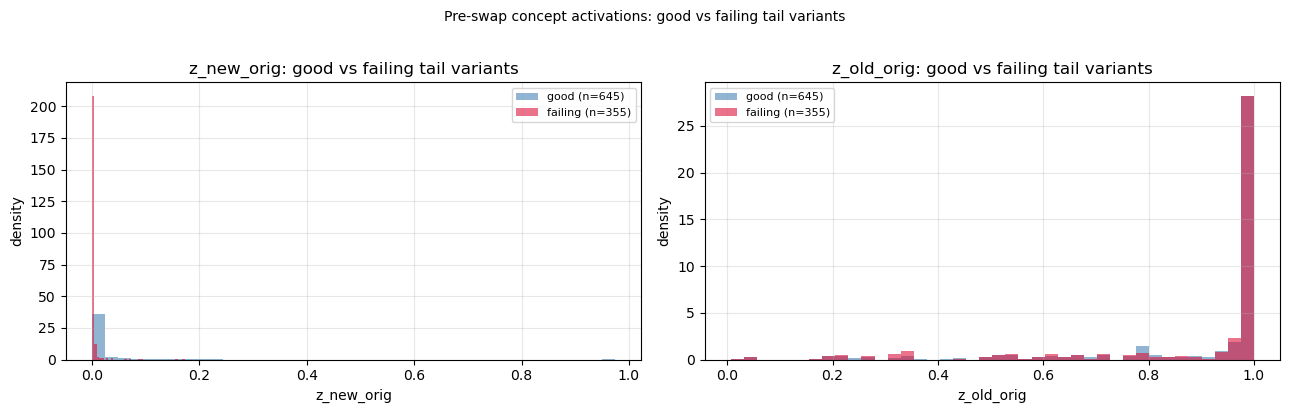

Saved fb_z_good_vs_failing_tail.png


In [50]:
if all_z_rows:
    tail_df  = z_order_df[z_order_df['part'] == 'tail'].copy()
    var_fc   = (tail_df.groupby('var_donor')['ordering_correct']
                .mean().rename('frac_correct').reset_index())
    median_fc = var_fc['frac_correct'].median()
    good_vars = set(var_fc[var_fc['frac_correct'] >= median_fc]['var_donor'])
    bad_vars  = set(var_fc[var_fc['frac_correct'] <  median_fc]['var_donor'])
    print(f'Median frac_correct across tail variants: {median_fc:.3f}')
    print(f'Good variants  (>= median): {sorted(good_vars)}')
    print(f'Failing variants (< median): {sorted(bad_vars)}')
    display(var_fc.sort_values('frac_correct'))

    tail_df['variant_group'] = tail_df['var_donor'].apply(
        lambda v: 'good' if v in good_vars else 'failing')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, col in zip(axes, ['z_new_orig', 'z_old_orig']):
        good_vals    = tail_df[tail_df['variant_group'] == 'good'][col]
        failing_vals = tail_df[tail_df['variant_group'] == 'failing'][col]
        bins = 40
        ax.hist(good_vals,    bins=bins, alpha=0.6, color='steelblue', density=True,
                label=f'good (n={len(good_vals)})')
        ax.hist(failing_vals, bins=bins, alpha=0.6, color='crimson',   density=True,
                label=f'failing (n={len(failing_vals)})')
        ax.set_xlabel(col); ax.set_ylabel('density')
        ax.set_title(f'{col}: good vs failing tail variants')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.suptitle('Pre-swap concept activations: good vs failing tail variants', y=1.02, fontsize=10)
    plt.tight_layout()
    plt.savefig('fb_z_good_vs_failing_tail.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_z_good_vs_failing_tail.png')


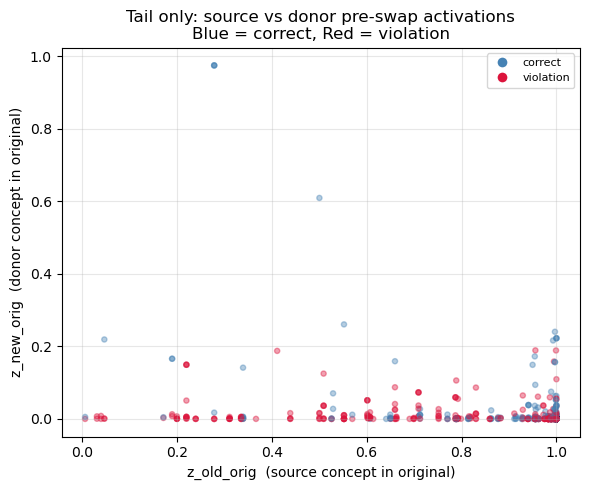

Saved fb_z_old_vs_new_orig_tail.png


In [51]:
if all_z_rows:
    from matplotlib.lines import Line2D
    tail_df = z_order_df[z_order_df['part'] == 'tail']
    colors  = tail_df['ordering_correct'].map({True: 'steelblue', False: 'crimson'})
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(tail_df['z_old_orig'], tail_df['z_new_orig'], c=colors, s=14, alpha=0.4)
    ax.set_xlabel('z_old_orig  (source concept in original)')
    ax.set_ylabel('z_new_orig  (donor concept in original)')
    ax.set_title('Tail only: source vs donor pre-swap activations\nBlue = correct, Red = violation')
    ax.grid(True, alpha=0.3)
    ax.legend(handles=[
        Line2D([0],[0],marker='o',color='w',markerfacecolor='steelblue',ms=8,label='correct'),
        Line2D([0],[0],marker='o',color='w',markerfacecolor='crimson', ms=8,label='violation'),
    ], fontsize=8)
    plt.tight_layout()
    plt.savefig('fb_z_old_vs_new_orig_tail.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_z_old_vs_new_orig_tail.png')


Good variants    [5, 8]: n=300
Failing variants [1, 2, 7]: n=245


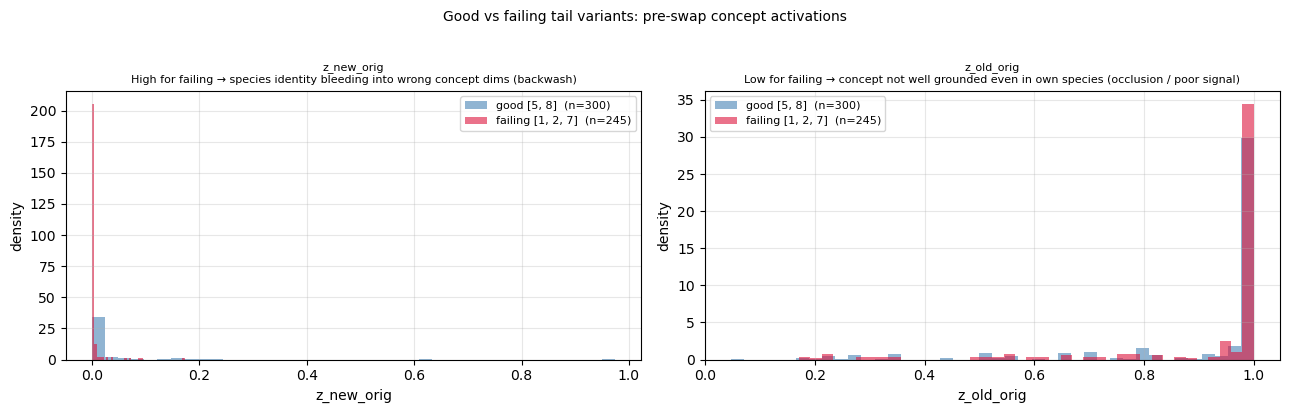

In [52]:
# Known from per-concept frac_correct table
TAIL_GOOD_VARS    = {5, 8}       # high frac_correct
TAIL_FAILING_VARS = {1, 2, 7}   # low frac_correct
# tail_0, tail_3, tail_4, tail_6 are intermediate — excluded

tail_df = z_order_df[z_order_df['part'] == 'tail'].copy()
tail_df['variant_group'] = tail_df['var_donor'].apply(
    lambda v: 'good'    if v in TAIL_GOOD_VARS    else
              'failing' if v in TAIL_FAILING_VARS else None
)
tail_cmp = tail_df[tail_df['variant_group'].notna()].copy()

print(f"Good variants    {sorted(TAIL_GOOD_VARS)}: "
      f"n={len(tail_cmp[tail_cmp['variant_group']=='good'])}")
print(f"Failing variants {sorted(TAIL_FAILING_VARS)}: "
      f"n={len(tail_cmp[tail_cmp['variant_group']=='failing'])}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, interp in [
    (axes[0], 'z_new_orig',
     'High for failing → species identity bleeding into wrong concept dims (backwash)'),
    (axes[1], 'z_old_orig',
     'Low for failing → concept not well grounded even in own species (occlusion / poor signal)'),
]:
    good_vals    = tail_cmp[tail_cmp['variant_group'] == 'good'][col]
    failing_vals = tail_cmp[tail_cmp['variant_group'] == 'failing'][col]
    bins = 40
    ax.hist(good_vals,    bins=bins, alpha=0.6, color='steelblue', density=True,
            label=f'good {sorted(TAIL_GOOD_VARS)}  (n={len(good_vals)})')
    ax.hist(failing_vals, bins=bins, alpha=0.6, color='crimson',   density=True,
            label=f'failing {sorted(TAIL_FAILING_VARS)}  (n={len(failing_vals)})')
    ax.set_xlabel(col); ax.set_ylabel('density')
    ax.set_title(f'{col}\n{interp}', fontsize=8)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Good vs failing tail variants: pre-swap concept activations', y=1.02, fontsize=10)
plt.tight_layout()
plt.savefig('fb_z_good_vs_failing_tail.png', dpi=150, bbox_inches='tight')
plt.show()

## Concept confusion for tail violations

For each tail **violation** (z_cf[c_src] >= z_cf[c_donor] after swap), which tail concept dimension has the highest z in the counterfactual? Systematic off-diagonal patterns = bottleneck mis-attributes part variants to wrong concept slots.

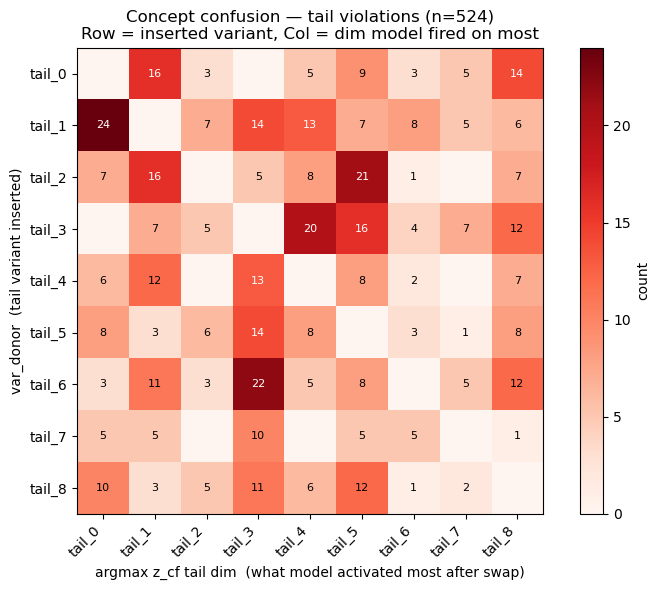

Saved fb_z_tail_confusion.png


In [53]:
if all_z_rows:
    import numpy as np
    n_tail    = PART_VARIANTS['tail']
    tail_df   = z_order_df[z_order_df['part'] == 'tail'].copy()
    tail_viol = tail_df[~tail_df['ordering_correct']]

    if tail_viol.empty:
        print('No tail violations — perfect grounding!')
    else:
        z_cf_tail_cols = [f'z_cf_tail_{i}' for i in range(n_tail)]
        missing = [c for c in z_cf_tail_cols if c not in tail_viol.columns]
        if missing:
            print(f'[WARNING] Missing columns {missing}.')
            print('Re-run the tail/all-parts loop with the updated z_ordering_record.')
        else:
            argmax_dim = tail_viol[z_cf_tail_cols].idxmax(axis=1).str.extract(r'(\d+)')[0].astype(int)
            tail_viol  = tail_viol.copy()
            tail_viol['argmax_tail_dim'] = argmax_dim.values

            conf = np.zeros((n_tail, n_tail), dtype=int)
            for _, row in tail_viol.iterrows():
                conf[int(row['var_donor']), int(row['argmax_tail_dim'])] += 1

            fig, ax = plt.subplots(figsize=(8, 6))
            im = ax.imshow(conf, cmap='Reds')
            ax.set_xticks(range(n_tail))
            ax.set_yticks(range(n_tail))
            ax.set_xticklabels([f'tail_{i}' for i in range(n_tail)], rotation=45, ha='right')
            ax.set_yticklabels([f'tail_{i}' for i in range(n_tail)])
            ax.set_xlabel('argmax z_cf tail dim  (what model activated most after swap)')
            ax.set_ylabel('var_donor  (tail variant inserted)')
            ax.set_title(f'Concept confusion — tail violations (n={len(tail_viol)})\n'
                         'Row = inserted variant, Col = dim model fired on most')
            for i in range(n_tail):
                for j in range(n_tail):
                    if conf[i, j] > 0:
                        ax.text(j, i, str(conf[i, j]), ha='center', va='center', fontsize=8,
                                color='white' if conf[i, j] > conf.max() * 0.5 else 'black')
            plt.colorbar(im, ax=ax, label='count')
            plt.tight_layout()
            plt.savefig('fb_z_tail_confusion.png', dpi=150, bbox_inches='tight')
            plt.show()
            print('Saved fb_z_tail_confusion.png')


Violations: 524
Anchoring (argmax == var_src, model did not update): 429 (81.9%)
Genuine confusion (argmax != var_src):               95 (18.1%)


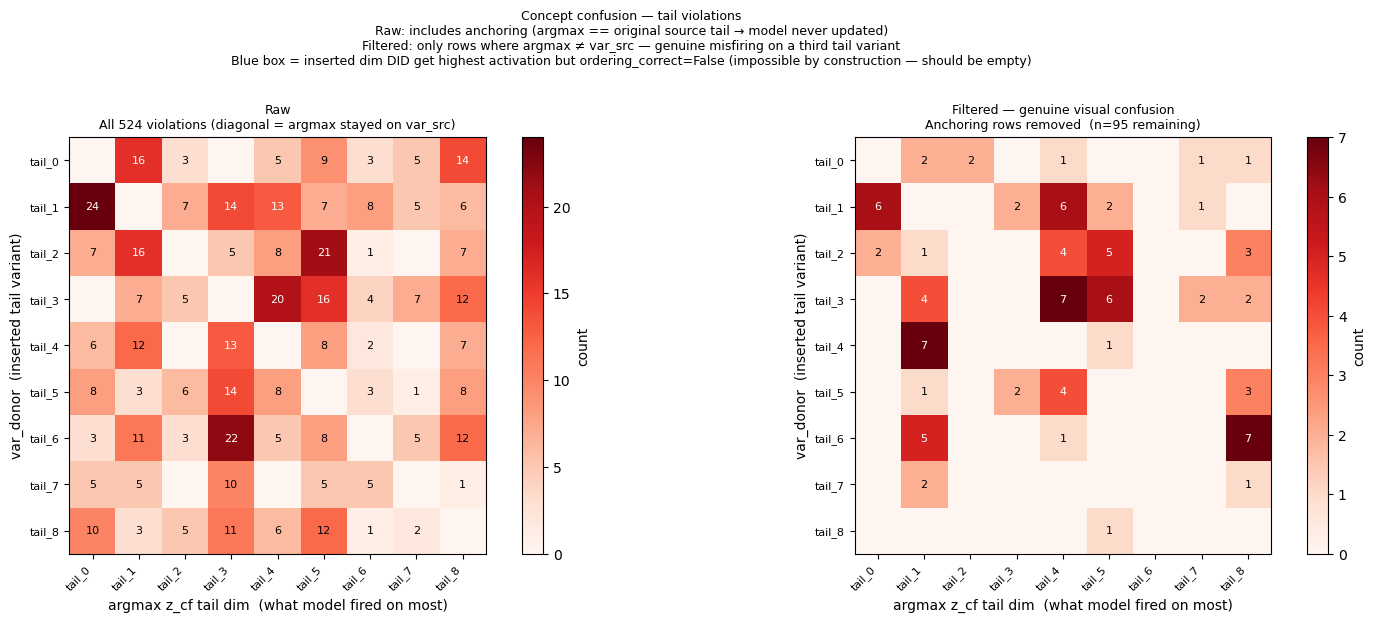

Saved fb_z_tail_confusion.png


In [94]:
if all_z_rows:
    n_tail    = PART_VARIANTS['tail']
    tail_df   = z_order_df[z_order_df['part'] == 'tail'].copy()
    tail_viol = tail_df[~tail_df['ordering_correct']].copy()
    z_cf_tail_cols = [f'z_cf_tail_{i}' for i in range(n_tail)]
    missing = [c for c in z_cf_tail_cols if c not in tail_viol.columns]

    if missing:
        print(f'[WARNING] Missing {missing}. Re-run loop with updated z_ordering_record.')
    elif tail_viol.empty:
        print('No tail violations.')
    else:
        argmax_dim = (tail_viol[z_cf_tail_cols]
                      .idxmax(axis=1).str.extract(r'(\d+)')[0].astype(int))
        tail_viol['argmax_tail_dim'] = argmax_dim.values
        # var_src IS the source species' original tail — check if model just stayed put
        tail_viol['is_anchoring'] = tail_viol['argmax_tail_dim'] == tail_viol['var_src']
        n_anch  = tail_viol['is_anchoring'].sum()
        n_total = len(tail_viol)
        print(f'Violations: {n_total}')
        print(f'Anchoring (argmax == var_src, model did not update): '
              f'{n_anch} ({n_anch/n_total:.1%})')
        print(f'Genuine confusion (argmax != var_src):               '
              f'{n_total-n_anch} ({(n_total-n_anch)/n_total:.1%})')

        def build_conf(df):
            c = np.zeros((n_tail, n_tail), dtype=int)
            for _, r in df.iterrows():
                c[int(r['var_donor']), int(r['argmax_tail_dim'])] += 1
            return c

        conf_raw  = build_conf(tail_viol)
        conf_filt = build_conf(tail_viol[~tail_viol['is_anchoring']])

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        for ax, conf, title, sub in [
            (axes[0], conf_raw,  'Raw',
             f'All {n_total} violations (diagonal = argmax stayed on var_src)'),
            (axes[1], conf_filt, 'Filtered — genuine visual confusion',
             f'Anchoring rows removed  (n={n_total-n_anch} remaining)'),
        ]:
            im = ax.imshow(conf, cmap='Reds')
            ax.set_xticks(range(n_tail)); ax.set_yticks(range(n_tail))
            ax.set_xticklabels([f'tail_{i}' for i in range(n_tail)],
                               rotation=45, ha='right', fontsize=8)
            ax.set_yticklabels([f'tail_{i}' for i in range(n_tail)], fontsize=8)
            ax.set_xlabel('argmax z_cf tail dim  (what model fired on most)')
            ax.set_ylabel('var_donor  (inserted tail variant)')
            ax.set_title(f'{title}\n{sub}', fontsize=9)
            for ii in range(n_tail):
                for jj in range(n_tail):
                    v = conf[ii, jj]
                    if v == 0: continue
                    # box the diagonal — var_donor==argmax (inserted variant DID fire but still lost)
                    if ii == jj:
                        ax.add_patch(plt.Rectangle(
                            (jj-.5, ii-.5), 1, 1, fill=False, edgecolor='blue', lw=2))
                    ax.text(jj, ii, str(v), ha='center', va='center', fontsize=8,
                            color='white' if v > conf.max()*.5 else 'black')
            plt.colorbar(im, ax=ax, label='count')

        plt.suptitle(
            'Concept confusion — tail violations\n'
            'Raw: includes anchoring (argmax == original source tail → model never updated)\n'
            'Filtered: only rows where argmax ≠ var_src — genuine misfiring on a third tail variant\n'
            'Blue box = inserted dim DID get highest activation but ordering_correct=False '
            '(impossible by construction — should be empty)',
            y=1.02, fontsize=9)
        plt.tight_layout()
        plt.savefig('fb_z_tail_confusion.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved fb_z_tail_confusion.png')

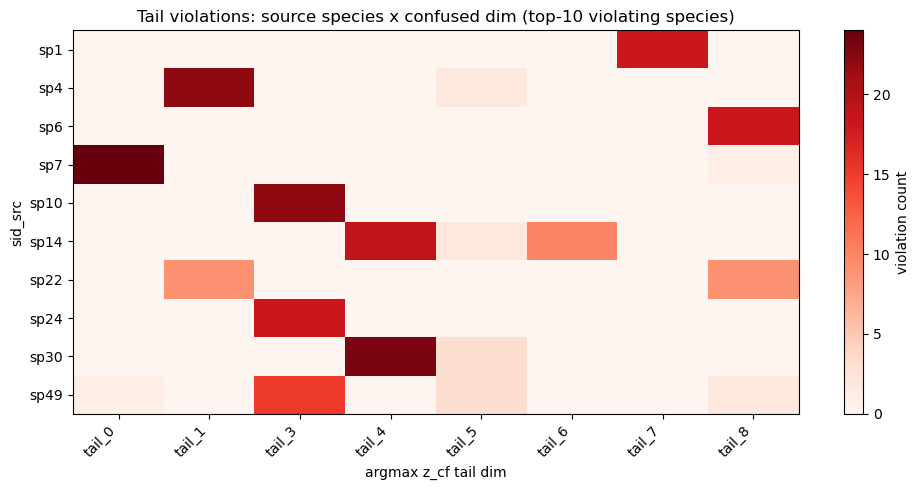

Saved fb_z_tail_confusion_by_species.png


In [54]:
if all_z_rows:
    n_tail    = PART_VARIANTS['tail']
    tail_df   = z_order_df[z_order_df['part'] == 'tail'].copy()
    tail_viol = tail_df[~tail_df['ordering_correct']]
    z_cf_tail_cols = [f'z_cf_tail_{i}' for i in range(n_tail)]

    if not tail_viol.empty and all(c in tail_viol.columns for c in z_cf_tail_cols):
        argmax_dim = tail_viol[z_cf_tail_cols].idxmax(axis=1).str.extract(r'(\d+)')[0].astype(int)
        tail_viol  = tail_viol.copy()
        tail_viol['argmax_tail_dim'] = argmax_dim.values

        top_sid   = tail_viol['sid_src'].value_counts().head(10).index.tolist()
        sc_pivot  = (tail_viol[tail_viol['sid_src'].isin(top_sid)]
                     .groupby(['sid_src', 'argmax_tail_dim']).size()
                     .reset_index(name='count')
                     .pivot(index='sid_src', columns='argmax_tail_dim', values='count')
                     .fillna(0).astype(int))

        fig, ax = plt.subplots(figsize=(10, 5))
        im = ax.imshow(sc_pivot.values, cmap='Reds', aspect='auto')
        ax.set_xticks(range(len(sc_pivot.columns)))
        ax.set_xticklabels([f'tail_{c}' for c in sc_pivot.columns], rotation=45, ha='right')
        ax.set_yticks(range(len(sc_pivot.index)))
        ax.set_yticklabels([f'sp{s}' for s in sc_pivot.index])
        ax.set_xlabel('argmax z_cf tail dim')
        ax.set_ylabel('sid_src')
        ax.set_title('Tail violations: source species x confused dim (top-10 violating species)')
        plt.colorbar(im, ax=ax, label='violation count')
        plt.tight_layout()
        plt.savefig('fb_z_tail_confusion_by_species.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved fb_z_tail_confusion_by_species.png')
    else:
        print('[skip] z_cf_tail columns not found — re-run loop with updated z_ordering_record.')


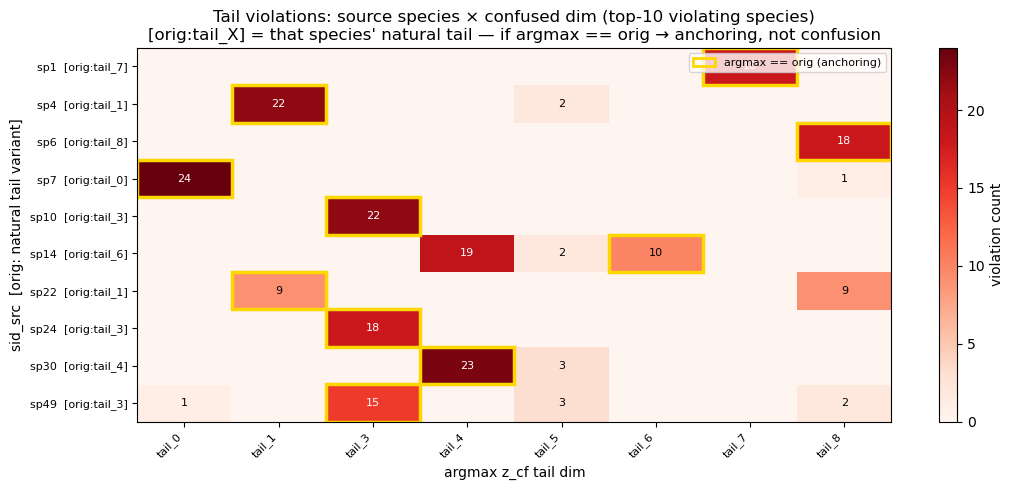

Saved fb_z_tail_confusion_by_species.png


In [95]:
if all_z_rows:
    n_tail    = PART_VARIANTS['tail']
    tail_df   = z_order_df[z_order_df['part'] == 'tail'].copy()
    tail_viol = tail_df[~tail_df['ordering_correct']].copy()
    z_cf_tail_cols = [f'z_cf_tail_{i}' for i in range(n_tail)]

    if not tail_viol.empty and all(c in tail_viol.columns for c in z_cf_tail_cols):
        argmax_dim = (tail_viol[z_cf_tail_cols]
                      .idxmax(axis=1).str.extract(r'(\d+)')[0].astype(int))
        tail_viol['argmax_tail_dim'] = argmax_dim.values
        tail_viol['is_anchoring']    = tail_viol['argmax_tail_dim'] == tail_viol['var_src']

        top_sid  = tail_viol['sid_src'].value_counts().head(10).index.tolist()
        sc_pivot = (tail_viol[tail_viol['sid_src'].isin(top_sid)]
                    .groupby(['sid_src', 'argmax_tail_dim']).size()
                    .reset_index(name='count')
                    .pivot(index='sid_src', columns='argmax_tail_dim', values='count')
                    .fillna(0).astype(int))

        # original tail variant per source species (for row labels)
        orig_var = {sid: species_variant_idx[sid]['tail'] for sid in top_sid}

        fig, ax = plt.subplots(figsize=(11, 5))
        im = ax.imshow(sc_pivot.values, cmap='Reds', aspect='auto')
        ax.set_xticks(range(len(sc_pivot.columns)))
        ax.set_xticklabels([f'tail_{c}' for c in sc_pivot.columns],
                           rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(sc_pivot.index)))
        # label format: sp7 [orig:3] — makes anchoring immediately visible
        ax.set_yticklabels(
            [f'sp{s}  [orig:tail_{orig_var[s]}]' for s in sc_pivot.index], fontsize=8)
        ax.set_xlabel('argmax z_cf tail dim')
        ax.set_ylabel('sid_src  [orig: natural tail variant]')
        ax.set_title(
            'Tail violations: source species × confused dim (top-10 violating species)\n'
            '[orig:tail_X] = that species\' natural tail — if argmax == orig → anchoring, not confusion')

        # draw a gold star on cells where argmax == orig (anchoring column for that species)
        for ri, sid in enumerate(sc_pivot.index):
            orig_col = orig_var[sid]
            if orig_col in sc_pivot.columns:
                ci = list(sc_pivot.columns).index(orig_col)
                ax.add_patch(plt.Rectangle(
                    (ci-.5, ri-.5), 1, 1, fill=False, edgecolor='gold', lw=2.5))

        for ii in range(len(sc_pivot.index)):
            for jj in range(len(sc_pivot.columns)):
                v = sc_pivot.values[ii, jj]
                if v > 0:
                    ax.text(jj, ii, str(v), ha='center', va='center', fontsize=8,
                            color='white' if v > sc_pivot.values.max()*.5 else 'black')

        plt.colorbar(im, ax=ax, label='violation count')
        from matplotlib.patches import Patch
        ax.legend(handles=[plt.Rectangle((0,0),1,1,fill=False,edgecolor='gold',lw=2,
                                         label='argmax == orig (anchoring)')],
                  loc='upper right', fontsize=8)
        plt.tight_layout()
        plt.savefig('fb_z_tail_confusion_by_species.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved fb_z_tail_confusion_by_species.png')
    else:
        print('[skip] z_cf_tail columns not found.')

## Source species breakdown

Which source species contribute most tail ordering violations? A high violation rate for specific species suggests the CBM anchors those species' concept activations to identity rather than visual evidence.

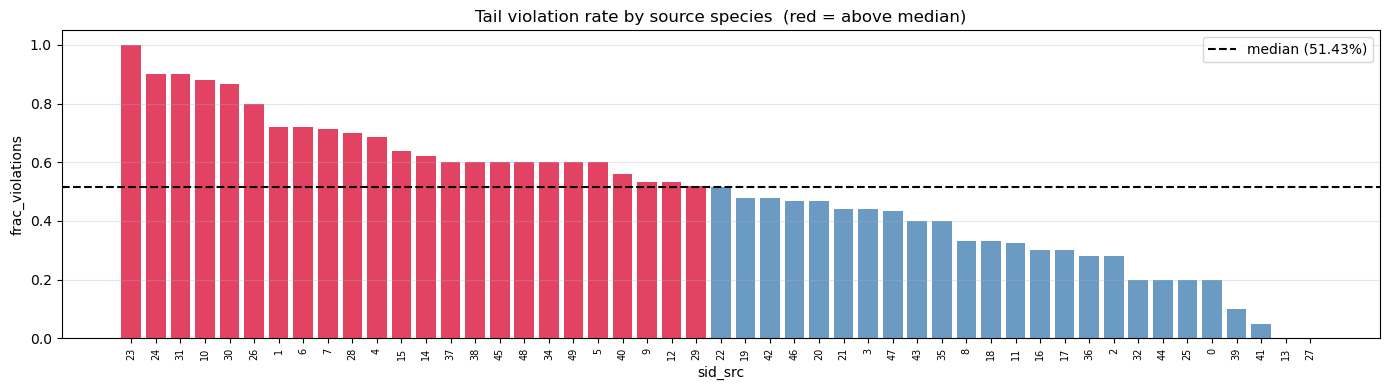

,sid_src,n_images,n_violations,frac_violations
23,23,15,15,1.000000
24,24,20,18,0.900000
31,31,10,9,0.900000
10,10,25,22,0.880000
30,30,30,26,0.866667
26,26,20,16,0.800000
1,1,25,18,0.720000
6,6,25,18,0.720000
7,7,35,25,0.714286
28,28,20,14,0.700000


In [55]:
if all_z_rows:
    tail_df = z_order_df[z_order_df['part'] == 'tail'].copy()
    viol_by_src = (tail_df.groupby('sid_src')
                   .agg(n_images=('ordering_correct', 'size'),
                        n_violations=('ordering_correct', lambda x: (~x).sum()),
                        frac_violations=('ordering_correct', lambda x: 1 - x.mean()))
                   .reset_index()
                   .sort_values('frac_violations', ascending=False))

    med = viol_by_src['frac_violations'].median()
    colors = ['crimson' if v > med else 'steelblue' for v in viol_by_src['frac_violations']]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(viol_by_src['sid_src'].astype(str), viol_by_src['frac_violations'],
           color=colors, alpha=0.8)
    ax.axhline(med, color='black', ls='--', lw=1.5, label=f'median ({med:.2%})')
    ax.set_xlabel('sid_src'); ax.set_ylabel('frac_violations')
    ax.set_title('Tail violation rate by source species  (red = above median)')
    ax.legend(); ax.grid(True, axis='y', alpha=0.3)
    plt.xticks(rotation=90, fontsize=7)
    plt.tight_layout()
    plt.savefig('fb_z_viol_by_sid_src.png', dpi=150, bbox_inches='tight')
    plt.show()
    display(viol_by_src.head(10))


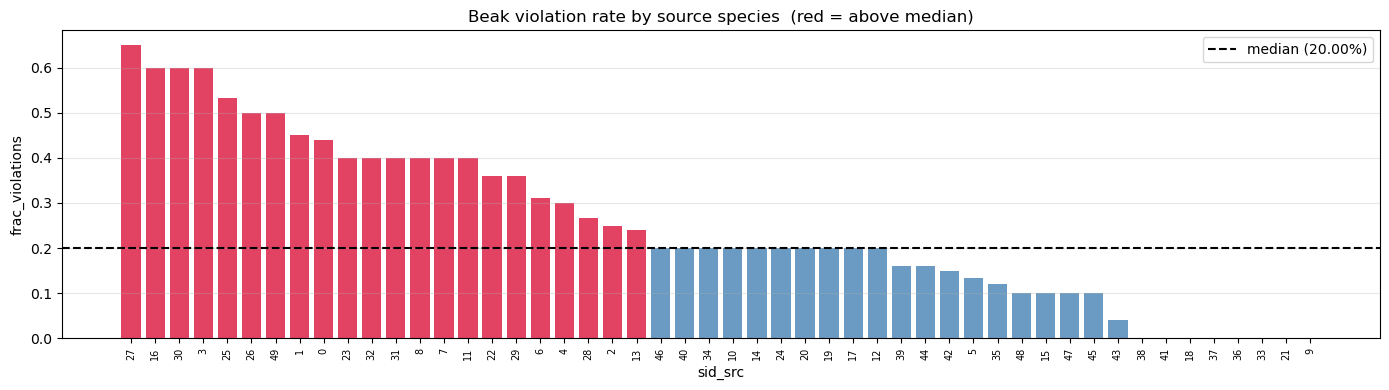

,sid_src,n_images,n_violations,frac_violations
27,27,20,13,0.650000
16,16,5,3,0.600000
30,30,5,3,0.600000
3,3,10,6,0.600000
25,25,15,8,0.533333
26,26,10,5,0.500000
49,49,10,5,0.500000
1,1,20,9,0.450000
0,0,25,11,0.440000
23,23,20,8,0.400000


In [75]:
if all_z_rows:
    tail_df = z_order_df[z_order_df['part'] == 'beak'].copy()
    viol_by_src = (tail_df.groupby('sid_src')
                   .agg(n_images=('ordering_correct', 'size'),
                        n_violations=('ordering_correct', lambda x: (~x).sum()),
                        frac_violations=('ordering_correct', lambda x: 1 - x.mean()))
                   .reset_index()
                   .sort_values('frac_violations', ascending=False))

    med = viol_by_src['frac_violations'].median()
    colors = ['crimson' if v > med else 'steelblue' for v in viol_by_src['frac_violations']]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(viol_by_src['sid_src'].astype(str), viol_by_src['frac_violations'],
           color=colors, alpha=0.8)
    ax.axhline(med, color='black', ls='--', lw=1.5, label=f'median ({med:.2%})')
    ax.set_xlabel('sid_src'); ax.set_ylabel('frac_violations')
    ax.set_title('Beak violation rate by source species  (red = above median)')
    ax.legend(); ax.grid(True, axis='y', alpha=0.3)
    plt.xticks(rotation=90, fontsize=7)
    plt.tight_layout()
    plt.savefig('fb_z_viol_by_sid_src.png', dpi=150, bbox_inches='tight')
    plt.show()
    display(viol_by_src.head(10))


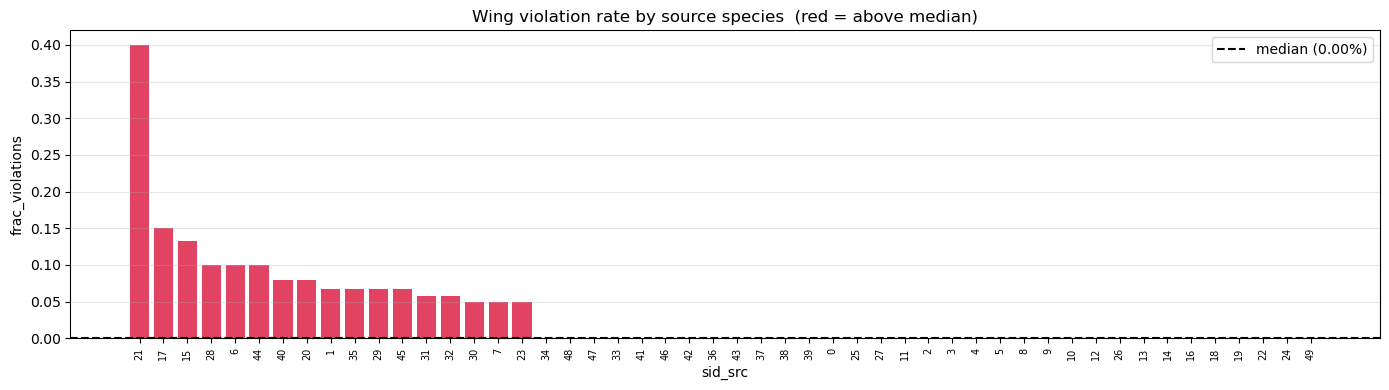

,sid_src,n_images,n_violations,frac_violations
21,21,15,6,0.400000
17,17,20,3,0.150000
15,15,15,2,0.133333
28,28,20,2,0.100000
6,6,30,3,0.100000
44,44,30,3,0.100000
40,40,25,2,0.080000
20,20,25,2,0.080000
1,1,15,1,0.066667
35,35,15,1,0.066667


In [73]:
if all_z_rows:
    tail_df = z_order_df[z_order_df['part'] == 'wing'].copy()
    viol_by_src = (tail_df.groupby('sid_src')
                   .agg(n_images=('ordering_correct', 'size'),
                        n_violations=('ordering_correct', lambda x: (~x).sum()),
                        frac_violations=('ordering_correct', lambda x: 1 - x.mean()))
                   .reset_index()
                   .sort_values('frac_violations', ascending=False))

    med = viol_by_src['frac_violations'].median()
    colors = ['crimson' if v > med else 'steelblue' for v in viol_by_src['frac_violations']]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(viol_by_src['sid_src'].astype(str), viol_by_src['frac_violations'],
           color=colors, alpha=0.8)
    ax.axhline(med, color='black', ls='--', lw=1.5, label=f'median ({med:.2%})')
    ax.set_xlabel('sid_src'); ax.set_ylabel('frac_violations')
    ax.set_title('Wing violation rate by source species  (red = above median)')
    ax.legend(); ax.grid(True, axis='y', alpha=0.3)
    plt.xticks(rotation=90, fontsize=7)
    plt.tight_layout()
    plt.savefig('fb_z_viol_by_sid_src.png', dpi=150, bbox_inches='tight')
    plt.show()
    display(viol_by_src.head(10))


Worst donor variant by violation count: tail_1


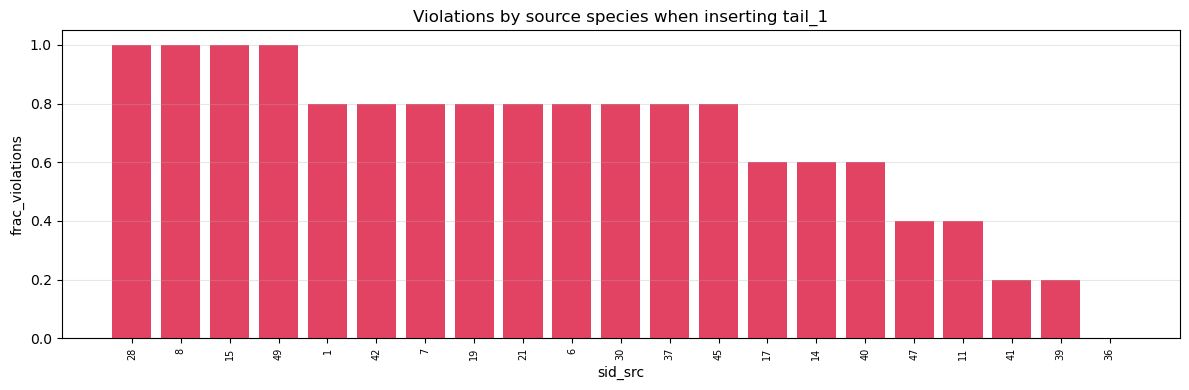

,sid_src,n_images,n_violations,frac_violations
10,28,5,5,1.0
3,8,5,5,1.0
6,15,5,5,1.0
20,49,5,5,1.0
0,1,5,4,0.8
17,42,5,4,0.8
2,7,5,4,0.8
8,19,5,4,0.8
9,21,5,4,0.8
1,6,5,4,0.8


In [56]:
if all_z_rows:
    tail_df = z_order_df[z_order_df['part'] == 'tail'].copy()

    # Identify worst donor variant from data
    worst_var = (tail_df[~tail_df['ordering_correct']]['var_donor']
                 .value_counts().idxmax())
    label = f'tail_{worst_var}'
    print(f'Worst donor variant by violation count: {label}')

    sub = tail_df[tail_df['var_donor'] == worst_var]
    viol_sub = (sub.groupby('sid_src')
                .agg(n_images=('ordering_correct', 'size'),
                     n_violations=('ordering_correct', lambda x: (~x).sum()),
                     frac_violations=('ordering_correct', lambda x: 1 - x.mean()))
                .reset_index()
                .sort_values('frac_violations', ascending=False))

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(viol_sub['sid_src'].astype(str), viol_sub['frac_violations'],
           color=PART_COLORS['tail'], alpha=0.8)
    ax.set_xlabel('sid_src'); ax.set_ylabel('frac_violations')
    ax.set_title(f'Violations by source species when inserting {label}')
    ax.grid(True, axis='y', alpha=0.3)
    plt.xticks(rotation=90, fontsize=7)
    plt.tight_layout()
    plt.savefig(f'fb_z_viol_by_sid_src_{label}.png', dpi=150, bbox_inches='tight')
    plt.show()
    display(viol_sub.head(10))


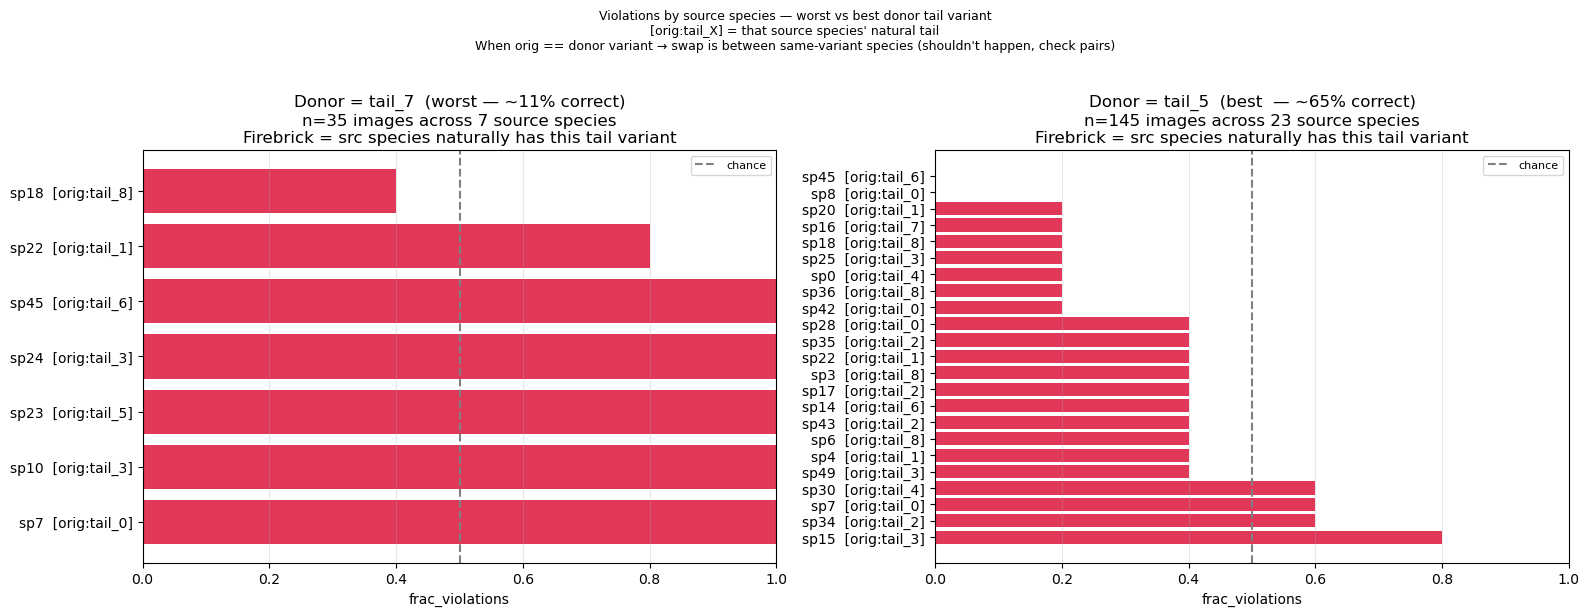

Saved fb_z_viol_contrast_tail7_tail5.png


In [96]:
if all_z_rows:
    tail_df = z_order_df[z_order_df['part'] == 'tail'].copy()
    tail_df['var_src_original'] = tail_df['sid_src'].map(
        lambda s: species_variant_idx[s]['tail'])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, donor_var, label in [
        (axes[0], 7, 'tail_7  (worst — ~11% correct)'),
        (axes[1], 5, 'tail_5  (best  — ~65% correct)'),
    ]:
        sub = tail_df[tail_df['var_donor'] == donor_var]
        if sub.empty:
            ax.set_title(f'No data for {label}'); continue

        viol_sub = (sub.groupby(['sid_src', 'var_src_original'])
                    .agg(n_images=('ordering_correct', 'size'),
                         frac_violations=('ordering_correct', lambda x: 1 - x.mean()))
                    .reset_index()
                    .sort_values('frac_violations', ascending=False))

        # highlight in red if var_src_original == donor_var
        # (source species already HAS this tail — trivially hard swap)
        bar_colors = ['firebrick' if r.var_src_original == donor_var else PART_COLORS['tail']
                      for _, r in viol_sub.iterrows()]
        ylabels = [f'sp{int(r.sid_src)}  [orig:tail_{int(r.var_src_original)}]'
                   for _, r in viol_sub.iterrows()]

        ax.barh(ylabels, viol_sub['frac_violations'], color=bar_colors, alpha=0.85)
        ax.axvline(0.5, color='gray', ls='--', lw=1.5, label='chance')
        ax.set_xlabel('frac_violations')
        ax.set_title(f'Donor = {label}\n'
                     f'n={len(sub)} images across {len(viol_sub)} source species\n'
                     'Firebrick = src species naturally has this tail variant')
        ax.set_xlim(0, 1)
        ax.legend(fontsize=8)
        ax.grid(True, axis='x', alpha=0.3)

    plt.suptitle(
        'Violations by source species — worst vs best donor tail variant\n'
        '[orig:tail_X] = that source species\' natural tail\n'
        'When orig == donor variant → swap is between same-variant species (shouldn\'t happen, check pairs)',
        y=1.02, fontsize=9)
    plt.tight_layout()
    plt.savefig('fb_z_viol_contrast_tail7_tail5.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_z_viol_contrast_tail7_tail5.png')

In [57]:
# Per-concept breakdown: which specific variant pairs have most violations?
if all_z_rows:
    concept_summary = (
        z_order_df.groupby(['part', 'c_donor'], as_index=False)
        .agg(
            concept       = ('part', lambda x: x.iloc[0]),  # placeholder
            n_images      = ('ordering_correct', 'size'),
            frac_correct  = ('ordering_correct', 'mean'),
            mean_margin   = ('margin', 'mean'),
        )
    )
    concept_summary['concept'] = concept_summary.apply(
        lambda r: CONCEPT_NAMES[int(r['c_donor'])], axis=1)
    concept_summary = concept_summary.sort_values('frac_correct').reset_index(drop=True)
    print('Worst concepts by ordering violation rate:')
    display(concept_summary.head(15))

Worst concepts by ordering violation rate:


,part,c_donor,concept,n_images,frac_correct,mean_margin
0,tail,24,tail_7,35,0.114286,-0.462647
1,tail,19,tail_2,85,0.235294,-0.247515
2,tail,18,tail_1,125,0.328000,-0.187716
3,beak,2,beak_2,190,0.357895,-0.111989
4,tail,23,tail_6,110,0.372727,-0.107107
5,tail,17,tail_0,95,0.421053,-0.018313
6,tail,21,tail_4,90,0.466667,0.005525
7,tail,20,tail_3,160,0.556250,0.125891
8,tail,22,tail_5,145,0.648276,0.359527
9,tail,25,tail_8,155,0.677419,0.384935


## Visual swap inspection grid

For a given (source species, donor species, part) swap, renders:
1. Source species original images
2. Source species part_map (how many tail pixels are present normally)
3. Counterfactual renders (swapped-in donor tail)
4. Counterfactual part_map (how many tail pixels visible after swap)
5. Donor species original images (what the inserted tail looks like in context)
6. Donor species part_map (donor tail pixel count in natural context)

Requires `render_part_map` from Part 2 setup cell.

In [ ]:
def plot_swap_inspection_grid(part, sid_src, sid_donor, n_src=3, n_donor=2):
    """Inspection grid: 6 columns × max(n_src, n_donor) rows."""
    src_idxs   = test_idx_by_species[sid_src][:n_src]
    donor_idxs = test_idx_by_species[sid_donor][:n_donor]
    nrows      = max(n_src, n_donor)

    var_src   = species_variant_idx[sid_src][part]
    var_donor = species_variant_idx[sid_donor][part]
    print(f'sp{sid_src} ({part}_{var_src})  ←  {part}_{var_donor} from sp{sid_donor}  '
          f'— rendering {n_src*2 + n_donor + 3} images...')

    # Pre-render everything (avoids repeated calls inside the plot loop)
    src_orig_imgs, src_cf_imgs = [], []
    for local_idx in src_idxs:
        ann      = test_anns[local_idx]
        ann_cf   = swap_part_in_ann(ann, part, species_part_params[sid_donor][part])
        src_orig_imgs.append(render_ann(ann))
        src_cf_imgs.append(render_ann(ann_cf))

    seg_src  = render_part_map(test_anns[src_idxs[0]])
    seg_cf   = render_part_map(
        swap_part_in_ann(test_anns[src_idxs[0]], part, species_part_params[sid_donor][part]))
    seg_donor = render_part_map(test_anns[donor_idxs[0]])

    px_src   = part_pixel_count(seg_src,   part)
    px_cf    = part_pixel_count(seg_cf,    part)
    px_donor = part_pixel_count(seg_donor, part)

    donor_imgs = [render_ann(test_anns[i]) for i in donor_idxs]

    # Build grid
    fig, axes = plt.subplots(nrows, 6, figsize=(18, nrows * 3.2))
    if nrows == 1:
        axes = axes[np.newaxis, :]

    col_titles = [
        f'sp{sid_src} original\n({part}_{var_src})',
        f'sp{sid_src} part_map\n({px_src} px)',
        f'sp{sid_src} ← {part}_{var_donor}\ncounterfactual',
        f'counterfactual part_map\n({px_cf} px)',
        f'sp{sid_donor} original\n({part}_{var_donor})',
        f'sp{sid_donor} part_map\n({px_donor} px)',
    ]
    for j, ct in enumerate(col_titles):
        axes[0, j].set_title(ct, fontsize=9, fontweight='bold')

    for r in range(nrows):
        for c in range(6):
            axes[r, c].axis('off')

        if r < n_src:
            axes[r, 0].imshow(src_orig_imgs[r]);  axes[r, 0].axis('on')
            axes[r, 2].imshow(src_cf_imgs[r]);    axes[r, 2].axis('on')
            if r == 0:
                axes[0, 1].imshow(seg_src);  axes[0, 1].axis('on')
                axes[0, 3].imshow(seg_cf);   axes[0, 3].axis('on')

        if r < n_donor:
            axes[r, 4].imshow(donor_imgs[r]); axes[r, 4].axis('on')
            if r == 0:
                axes[0, 5].imshow(seg_donor); axes[0, 5].axis('on')

        for c in range(6):
            axes[r, c].set_xticks([]); axes[r, c].set_yticks([])

    plt.suptitle(
        f'Swap inspection: sp{sid_src} [{part}_{var_src}] ← {part}_{var_donor} from sp{sid_donor}\n'
        f'part_map pixel counts — original src: {px_src}px  |  cf: {px_cf}px  |  donor: {px_donor}px',
        y=1.01, fontsize=10)
    plt.tight_layout()
    fname = f'fb_inspect_{part}_sp{sid_src}_donor{sid_donor}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')

print('Defined: plot_swap_inspection_grid')

In [ ]:
# Find worst donor species per source species in beak violations
# Then call grid for each (src, donor) pair
if all_z_rows:
    beak_viol = z_order_df[(z_order_df['part'] == 'beak') &
                           (~z_order_df['ordering_correct'])]

    # For each target source species, find most common donor in violations
    target_srcs = [7, 23, 27]   # high-violation beak source species
    for sid_src in target_srcs:
        sub = beak_viol[beak_viol['sid_src'] == sid_src]
        if sub.empty:
            print(f'sp{sid_src}: no beak violations found'); continue
        sid_donor = int(sub['sid_donor'].value_counts().idxmax())
        print(f'\n--- sp{sid_src} — worst donor: sp{sid_donor} ---')
        plot_swap_inspection_grid('beak', sid_src, sid_donor)
else:
    # If all-parts loop not yet run, call manually with known pairs:
    # plot_swap_inspection_grid('beak', 7, <donor_sid>)
    print('[no data] Run all-parts loop first, or specify donor manually.')

## 9. Diagnostic plots

## Downstream probability effect

How does the z-ordering margin relate to downstream species probability? Does the GT intervention ceiling (`p_gt_donor`) predict what the render swap achieves (`p_cf_donor`)?

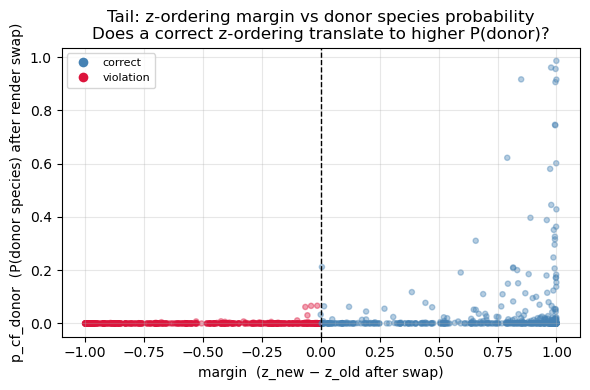

Saved fb_z_margin_vs_p_cf.png


In [58]:
if all_z_rows:
    from matplotlib.lines import Line2D
    tail_df = z_order_df[z_order_df['part'] == 'tail']
    colors  = tail_df['ordering_correct'].map({True: 'steelblue', False: 'crimson'})
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(tail_df['margin'], tail_df['p_cf_donor'], c=colors, s=14, alpha=0.4)
    ax.axvline(0, color='black', ls='--', lw=1)
    ax.set_xlabel('margin  (z_new − z_old after swap)')
    ax.set_ylabel('p_cf_donor  (P(donor species) after render swap)')
    ax.set_title('Tail: z-ordering margin vs donor species probability\n'
                 'Does a correct z-ordering translate to higher P(donor)?')
    ax.grid(True, alpha=0.3)
    ax.legend(handles=[
        Line2D([0],[0],marker='o',color='w',markerfacecolor='steelblue',ms=8,label='correct'),
        Line2D([0],[0],marker='o',color='w',markerfacecolor='crimson', ms=8,label='violation'),
    ], fontsize=8)
    plt.tight_layout()
    plt.savefig('fb_z_margin_vs_p_cf.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_z_margin_vs_p_cf.png')


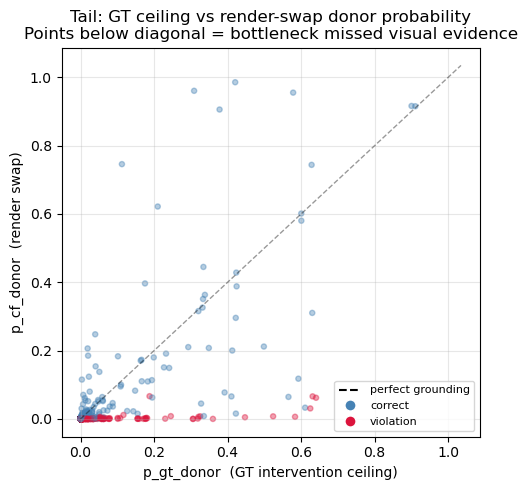

Saved fb_z_p_gt_vs_p_cf_tail.png


In [59]:
if all_z_rows:
    from matplotlib.lines import Line2D
    tail_df = z_order_df[z_order_df['part'] == 'tail']
    colors  = tail_df['ordering_correct'].map({True: 'steelblue', False: 'crimson'})
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(tail_df['p_gt_donor'], tail_df['p_cf_donor'], c=colors, s=14, alpha=0.4)
    _lim = max(tail_df['p_gt_donor'].max(), tail_df['p_cf_donor'].max()) * 1.05
    ax.plot([0, _lim], [0, _lim], 'k--', alpha=0.4, lw=1, label='perfect grounding')
    ax.set_xlabel('p_gt_donor  (GT intervention ceiling)')
    ax.set_ylabel('p_cf_donor  (render swap)')
    ax.set_title('Tail: GT ceiling vs render-swap donor probability\n'
                 'Points below diagonal = bottleneck missed visual evidence')
    ax.grid(True, alpha=0.3)
    ax.legend(handles=[
        Line2D([0],[0],linestyle='--',color='black',label='perfect grounding'),
        Line2D([0],[0],marker='o',color='w',markerfacecolor='steelblue',ms=8,label='correct'),
        Line2D([0],[0],marker='o',color='w',markerfacecolor='crimson', ms=8,label='violation'),
    ], fontsize=8)
    plt.tight_layout()
    plt.savefig('fb_z_p_gt_vs_p_cf_tail.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_z_p_gt_vs_p_cf_tail.png')


In [61]:
print(part_summary.columns.tolist())
print(part_summary.head())

['part', 'n_images', 'frac_correct', 'mean_margin', 'std_margin', 'frac_violations', 'mean_p_cf_donor', 'mean_p_gt_donor']
   part  n_images  frac_correct  mean_margin  std_margin  frac_violations  \
0  tail      1000         0.476     0.058219    0.688729            0.524   
1  beak      1000         0.762     0.482622    0.599867            0.238   
2   eye      1000         0.871     0.720976    0.507817            0.129   
3  foot      1000         0.966     0.883631    0.309973            0.034   
4  wing      1000         0.966     0.841114    0.332220            0.034   

   mean_p_cf_donor  mean_p_gt_donor  
0         0.019108         0.031525  
1         0.025227         0.023569  
2         0.040753         0.038881  
3         0.056208         0.043076  
4         0.054828         0.027602  


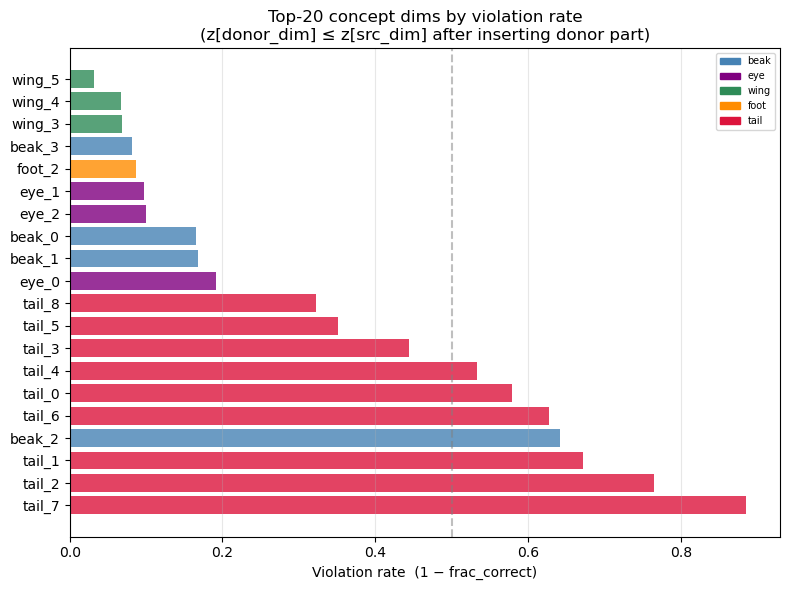

Saved fb_z_violation_by_concept.png


In [63]:
# Plot: violation rate per concept (top-20 worst)
if all_z_rows:
    fig, ax = plt.subplots(figsize=(8, 6))

    cs = concept_summary.sort_values('frac_correct').head(20)
    ax.barh(cs['concept'], 1 - cs['frac_correct'],
            color=[PART_COLORS[CONCEPT_TO_PART[c]] for c in cs['concept']], alpha=0.8)
    ax.axvline(0.5, color='gray', ls='--', alpha=0.5, label='chance')
    ax.set_xlabel('Violation rate  (1 − frac_correct)')
    ax.set_title('Top-20 concept dims by violation rate\n'
                 '(z[donor_dim] ≤ z[src_dim] after inserting donor part)')
    ax.legend(handles=[Patch(color=c, label=p) for p, c in PART_COLORS.items()], fontsize=7)
    ax.grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig('fb_z_violation_by_concept.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_z_violation_by_concept.png')

In [62]:
if all_z_rows:
    print('=== Z-ORDERING EXPERIMENT SUMMARY ===')
    print(f'Total images tested: {len(z_order_df)}')
    print(f'Parts: {sorted(z_order_df["part"].unique())}')
    print()
    print(f'{"part":6s}  {"frac_correct":>13s}  {"mean_margin":>12s}  '
          f'{"std_margin":>11s}  {"n_images":>9s}')
    print('-' * 58)
    for _, r in part_summary.iterrows():
        print(f'{r["part"]:6s}  {r["frac_correct"]:>13.3%}  '
              f'{r["mean_margin"]:>+12.4f}  '
              f'{r["std_margin"]:>+11.4f}  '
              f'{int(r["n_images"]):>9d}')
    print()
    _worst = part_summary.iloc[0]
    _best  = part_summary.iloc[-1]
    print(f'Most violated part:  {_worst["part"]}  ({_worst["frac_violations"]:.1%} violations)')
    print(f'Best grounded part:  {_best["part"]}   ({_best["frac_violations"]:.1%} violations)')
    print()
    print('Interpretation:')
    print('  frac_correct < 100%  -> bottleneck not fully visually grounded')
    print('  mean_margin  < 0     -> model actively inverts the expected ordering')
    print('  See confusion matrix for systematic mis-attribution patterns')
else:
    print('No results — run renderer cells first.')


=== Z-ORDERING EXPERIMENT SUMMARY ===
Total images tested: 5000
Parts: ['beak', 'eye', 'foot', 'tail', 'wing']

part     frac_correct   mean_margin   std_margin   n_images
----------------------------------------------------------
tail          47.600%       +0.0582      +0.6887       1000
beak          76.200%       +0.4826      +0.5999       1000
eye           87.100%       +0.7210      +0.5078       1000
foot          96.600%       +0.8836      +0.3100       1000
wing          96.600%       +0.8411      +0.3322       1000

Most violated part:  tail  (52.4% violations)
Best grounded part:  wing   (3.4% violations)

Interpretation:
  frac_correct < 100%  -> bottleneck not fully visually grounded
  mean_margin  < 0     -> model actively inverts the expected ordering
  See confusion matrix for systematic mis-attribution patterns


## 8. Part 2 — Segmentation / Occlusion Analysis

Tests whether z-ordering violations are explained by **occlusion** (the renderer
places a body part behind other geometry, making it nearly invisible) versus true
**concept backwash** (species-identity signal leaking into concept neurons even
when the part is clearly visible).

Pipeline:
1. Re-render each counterfactual image with `render_mode=part_map` → count pixels of swapped-in part (`pixel_count_cf`)
2. Characterise visibility distributions per part and per tail variant
3. Scatter `pixel_count_cf` vs `margin` — does low visibility predict violations?
4. Re-run aggregate with `MIN_PART_PIXELS` filter; compare `frac_correct` before vs after
   - If tail `frac_correct` rises after filtering → occlusion explains violations
   - If it stays near chance → backwash is the explanation

  beak :   141 px
  eye  :     0 px
  wing :     0 px
  foot :   125 px
  tail :    49 px


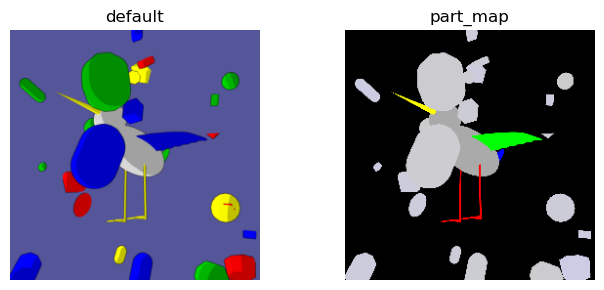

Smoke test OK


In [77]:
import threading, itertools

# Segmentation colours emitted by render_mode=part_map (exact RGB, 8-bit)
PART_SEG_COLORS = {
    'beak': (255, 255,   0),
    'eye':  (255, 255, 253),
    'wing': (  0, 255,   1),
    'foot': (255,   0,   1),
    'tail': (  0,   0, 255),
}

_port_lock  = threading.Lock()
_port_cycle = itertools.cycle(alive_ports if 'alive_ports' in globals() else [8081])

def render_part_map(ann: dict) -> Image.Image:
    """Render ann with render_mode=part_map using port cycling. Returns 256×256 RGB."""
    with _port_lock:
        port = next(_port_cycle)
    url = json_to_url(ann, prefix=f'http://localhost:{port}/render?', render_mode='part_map')
    resp = requests.get(url, timeout=15)
    resp.raise_for_status()
    img_bytes = decodebytes(resp.content)
    return Image.open(io.BytesIO(img_bytes)).convert('RGB').resize((256, 256), Image.NEAREST)


def part_pixel_count(img_seg: Image.Image, part: str) -> int:
    """Count pixels matching the segmentation colour for `part`."""
    arr = np.array(img_seg)
    r, g, b = PART_SEG_COLORS[part]
    mask = (arr[:, :, 0] == r) & (arr[:, :, 1] == g) & (arr[:, :, 2] == b)
    return int(mask.sum())


# ── Smoke test ────────────────────────────────────────────────────────────────
if RENDERER_AVAILABLE:
    _ann_st = test_anns[test_idx_by_species[0][0]]
    _seg    = render_part_map(_ann_st)
    for _p in PARTS:
        print(f'  {_p:5s}: {part_pixel_count(_seg, _p):5d} px')

    fig, axes = plt.subplots(1, 2, figsize=(7, 3))
    axes[0].imshow(render_ann(_ann_st));    axes[0].set_title('default');  axes[0].axis('off')
    axes[1].imshow(_seg);                   axes[1].set_title('part_map'); axes[1].axis('off')
    plt.tight_layout(); plt.show()
    print('Smoke test OK')
else:
    print('[skip] Renderer not available.')

In [82]:
def z_ordering_record_v2(
    ann_orig: dict,
    sid_src: int,
    part: str,
    var_src: int,
    sid_donor: int,
    var_donor: int,
    z_orig: torch.Tensor,
) -> dict:
    """Like z_ordering_record but adds pixel_count_cf via a part_map render.
    Costs 2 renderer calls per image instead of 1."""
    c_src   = CONCEPT_TO_IDX[f'{part}_{var_src}']
    c_donor = CONCEPT_TO_IDX[f'{part}_{var_donor}']

    ann_cf         = swap_part_in_ann(ann_orig, part, species_part_params[sid_donor][part])
    img_cf         = render_ann(ann_cf)
    img_seg        = render_part_map(ann_cf)
    z_cf, p_cf     = run_through_cbm(img_cf)

    z_new  = float(z_cf[c_donor])
    z_old  = float(z_cf[c_src])
    margin = z_new - z_old

    z_gt          = z_orig.clone()
    z_gt[c_donor] = 1.0
    z_gt[c_src]   = 0.0
    p_gt          = z_to_probs(z_gt)

    row = {
        'sid_src':          sid_src,
        'sid_donor':        sid_donor,
        'part':             part,
        'var_src':          var_src,
        'var_donor':        var_donor,
        'c_src':            c_src,
        'c_donor':          c_donor,
        'z_new':            z_new,
        'z_old':            z_old,
        'z_new_orig':       float(z_orig[c_donor]),
        'z_old_orig':       float(z_orig[c_src]),
        'margin':           margin,
        'ordering_correct': bool(margin > 0),
        'p_cf_donor':       float(p_cf[sid_donor]),
        'p_gt_donor':       float(p_gt[sid_donor]),
        'pixel_count_cf':   part_pixel_count(img_seg, part),
    }
    if part == 'tail':
        for i in range(PART_VARIANTS['tail']):
            row[f'z_cf_tail_{i}'] = float(z_cf[CONCEPT_TO_IDX[f'tail_{i}']])
    return row

print('Defined: z_ordering_record_v2')

Defined: z_ordering_record_v2


In [85]:
tail_z_rows_v2 = []

if not RENDERER_AVAILABLE:
    print('[SKIP] Renderer not available.')
else:
    for sid_A, var_A, sid_B, var_B in tqdm(_run_z_tail, desc='tail z-ordering v2'):
        for local_idx in test_idx_by_species[sid_A][:MAX_IMGS_PER_SPECIES]:
            gid = _FUNNYBIRDS_N_TRAIN + local_idx
            row = id_to_row_te.get(gid)
            if row is None: continue
            r = z_ordering_record_v2(
                test_anns[local_idx], sid_A, 'tail', var_A, sid_B, var_B, z_te[row])
            r['direction'] = 'fwd'
            tail_z_rows_v2.append(r)

        for local_idx in test_idx_by_species[sid_B][:MAX_IMGS_PER_SPECIES]:
            gid = _FUNNYBIRDS_N_TRAIN + local_idx
            row = id_to_row_te.get(gid)
            if row is None: continue
            r = z_ordering_record_v2(
                test_anns[local_idx], sid_B, 'tail', var_B, sid_A, var_A, z_te[row])
            r['direction'] = 'bwd'
            tail_z_rows_v2.append(r)

    print(f'Tail v2 rows: {len(tail_z_rows_v2)}')
    _df2 = pd.DataFrame(tail_z_rows_v2)
    print(f'  ordering_correct: {_df2["ordering_correct"].mean():.3%}')
    print(f'  median pixel_count_cf: {_df2["pixel_count_cf"].median():.0f}')

tail z-ordering v2:   0%|          | 0/100 [00:00<?, ?it/s]

[renderer] crash detected, restarting (attempt 1)...
Tail v2 rows: 1000
  ordering_correct: 47.600%
  median pixel_count_cf: 34


In [98]:
all_z_rows_v2 = list(tail_z_rows_v2)

if not RENDERER_AVAILABLE:
    print('[SKIP] Renderer not available.')
else:
    for part in [p for p in PARTS if p != 'tail']:
        _pairs = [
            (sid_A, species_variant_idx[sid_A][part],
             sid_B, species_variant_idx[sid_B][part])
            for sid_A, sid_B in combinations(range(N_SPECIES), 2)
            if species_variant_idx[sid_A][part] != species_variant_idx[sid_B][part]
        ]
        if MAX_PAIRS_PER_PART is not None and len(_pairs) > MAX_PAIRS_PER_PART:
            _pairs = random.Random(42).sample(_pairs, MAX_PAIRS_PER_PART)
        print(f'{part}: {len(_pairs)} pairs')

        for sid_A, var_A, sid_B, var_B in tqdm(_pairs, desc=part):
            for local_idx in test_idx_by_species[sid_A][:MAX_IMGS_PER_SPECIES]:
                gid = _FUNNYBIRDS_N_TRAIN + local_idx
                row = id_to_row_te.get(gid)
                if row is None: continue
                r = z_ordering_record_v2(
                    test_anns[local_idx], sid_A, part, var_A, sid_B, var_B, z_te[row])
                r['direction'] = 'fwd'
                all_z_rows_v2.append(r)

            for local_idx in test_idx_by_species[sid_B][:MAX_IMGS_PER_SPECIES]:
                gid = _FUNNYBIRDS_N_TRAIN + local_idx
                row = id_to_row_te.get(gid)
                if row is None: continue
                r = z_ordering_record_v2(
                    test_anns[local_idx], sid_B, part, var_B, sid_A, var_A, z_te[row])
                r['direction'] = 'bwd'
                all_z_rows_v2.append(r)

        _pdf = pd.DataFrame([r for r in all_z_rows_v2 if r['part'] == part])
        print(f'  ordering_correct: {_pdf["ordering_correct"].mean():.3%}  '
              f'median px: {_pdf["pixel_count_cf"].median():.0f}')

beak: 100 pairs


beak:   0%|          | 0/100 [00:00<?, ?it/s]

[renderer] crash detected, restarting (attempt 1)...
  ordering_correct: 76.000%  median px: 104
eye: 100 pairs


eye:   0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
all_z_rows_v2 = list(tail_z_rows_v2)

if not RENDERER_AVAILABLE:
    print('[SKIP] Renderer not available.')
else:
    for part in [p for p in PARTS if (p != 'tail' and p != 'beak')]:
        _pairs = [
            (sid_A, species_variant_idx[sid_A][part],
             sid_B, species_variant_idx[sid_B][part])
            for sid_A, sid_B in combinations(range(N_SPECIES), 2)
            if species_variant_idx[sid_A][part] != species_variant_idx[sid_B][part]
        ]
        if MAX_PAIRS_PER_PART is not None and len(_pairs) > MAX_PAIRS_PER_PART:
            _pairs = random.Random(42).sample(_pairs, MAX_PAIRS_PER_PART)
        print(f'{part}: {len(_pairs)} pairs')

        for sid_A, var_A, sid_B, var_B in tqdm(_pairs, desc=part):
            for local_idx in test_idx_by_species[sid_A][:MAX_IMGS_PER_SPECIES]:
                gid = _FUNNYBIRDS_N_TRAIN + local_idx
                row = id_to_row_te.get(gid)
                if row is None: continue
                r = z_ordering_record_v2(
                    test_anns[local_idx], sid_A, part, var_A, sid_B, var_B, z_te[row])
                r['direction'] = 'fwd'
                all_z_rows_v2.append(r)

            for local_idx in test_idx_by_species[sid_B][:MAX_IMGS_PER_SPECIES]:
                gid = _FUNNYBIRDS_N_TRAIN + local_idx
                row = id_to_row_te.get(gid)
                if row is None: continue
                r = z_ordering_record_v2(
                    test_anns[local_idx], sid_B, part, var_B, sid_A, var_A, z_te[row])
                r['direction'] = 'bwd'
                all_z_rows_v2.append(r)

        _pdf = pd.DataFrame([r for r in all_z_rows_v2 if r['part'] == part])
        print(f'  ordering_correct: {_pdf["ordering_correct"].mean():.3%}  '
              f'median px: {_pdf["pixel_count_cf"].median():.0f}')

eye: 100 pairs


eye:   0%|          | 0/100 [00:00<?, ?it/s]

[renderer] crash detected, restarting (attempt 1)...


In [99]:
if all_z_rows_v2:
    z_order_df_v2 = pd.DataFrame(all_z_rows_v2)
    z_order_df_v2.to_csv('fb_cbm_z_ordering_v2.csv', index=False)
    print(f'Saved fb_cbm_z_ordering_v2.csv  ({len(z_order_df_v2)} rows)')
    print(z_order_df_v2[['part','pixel_count_cf','ordering_correct','margin']].describe().round(2))
else:
    print('[no data] Run loops above first.')

Saved fb_cbm_z_ordering_v2.csv  (2013 rows)
       pixel_count_cf   margin
count         2013.00  2013.00
mean           133.03     0.27
std            152.34     0.68
min              0.00    -1.00
25%             17.00    -0.26
50%             78.00     0.43
75%            198.00     0.97
max           1253.00     1.00


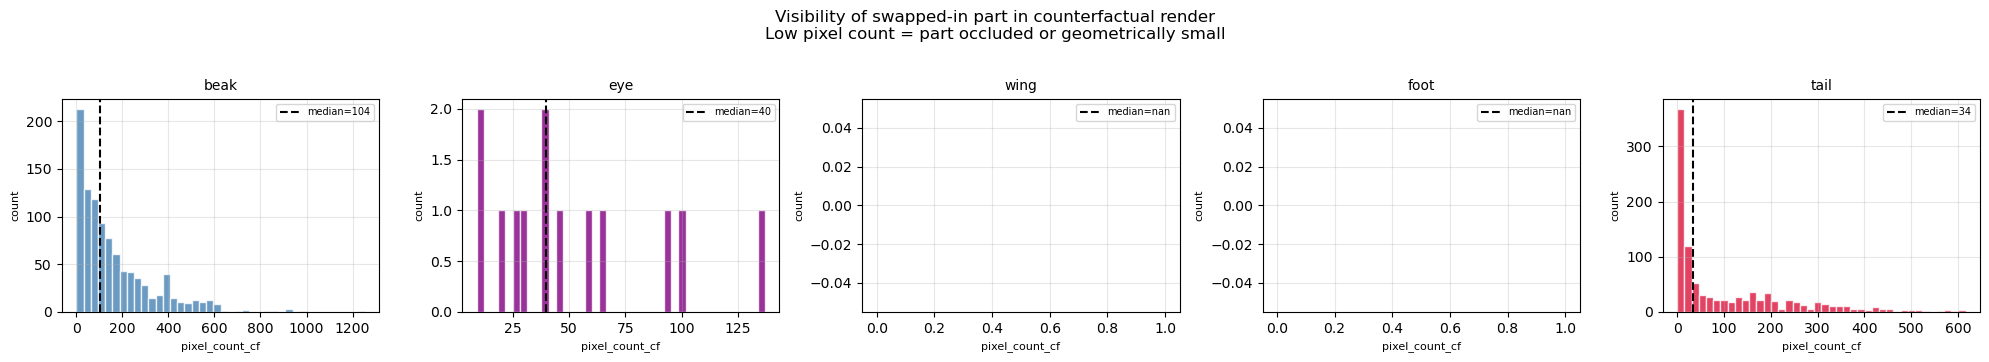

Saved fb_seg_pixel_hist_by_part.png


In [100]:
if all_z_rows_v2:
    fig, axes = plt.subplots(1, len(PARTS), figsize=(4 * len(PARTS), 3.5), sharey=False)
    for ax, part in zip(axes, PARTS):
        sub = z_order_df_v2[z_order_df_v2['part'] == part]['pixel_count_cf']
        ax.hist(sub, bins=40, color=PART_COLORS[part], alpha=0.8, edgecolor='white')
        ax.axvline(sub.median(), color='black', ls='--', lw=1.5, label=f'median={sub.median():.0f}')
        ax.set_title(part, fontsize=10)
        ax.set_xlabel('pixel_count_cf', fontsize=8)
        ax.set_ylabel('count', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
    plt.suptitle('Visibility of swapped-in part in counterfactual render\n'
                 'Low pixel count = part occluded or geometrically small', y=1.02)
    plt.tight_layout()
    plt.savefig('fb_seg_pixel_hist_by_part.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_seg_pixel_hist_by_part.png')

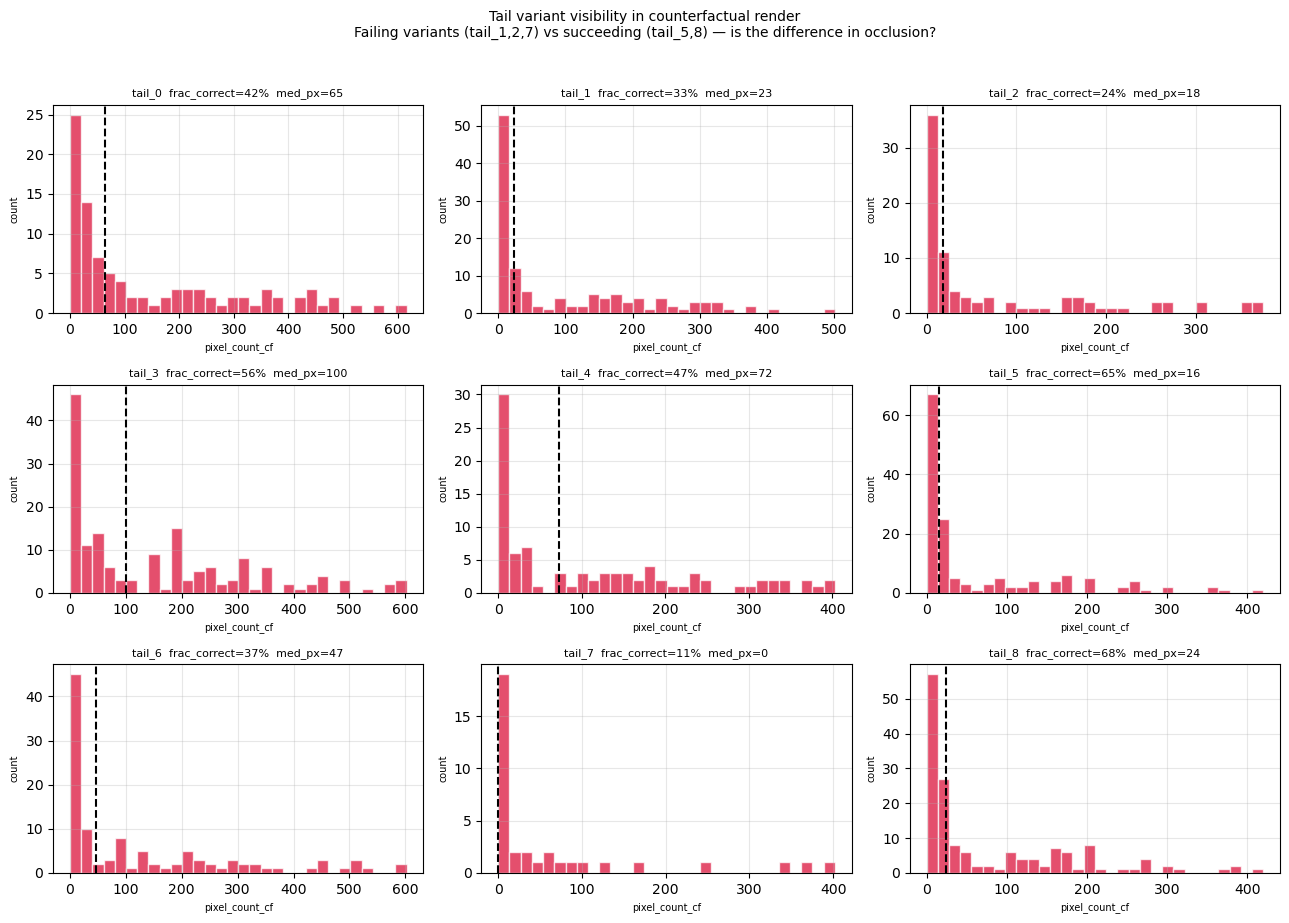

Saved fb_seg_tail_pixel_by_variant.png


In [101]:
if all_z_rows_v2:
    n_tail  = PART_VARIANTS['tail']
    tail_v2 = z_order_df_v2[z_order_df_v2['part'] == 'tail'].copy()

    fig, axes = plt.subplots(3, 3, figsize=(13, 9))
    axes = axes.flatten()
    for i in range(n_tail):
        ax  = axes[i]
        sub = tail_v2[tail_v2['var_donor'] == i]['pixel_count_cf']
        if sub.empty:
            ax.set_visible(False); continue
        fc  = tail_v2[tail_v2['var_donor'] == i]['ordering_correct'].mean()
        ax.hist(sub, bins=30, color=PART_COLORS['tail'], alpha=0.75, edgecolor='white')
        ax.axvline(sub.median(), color='black', ls='--', lw=1.5)
        ax.set_title(f'tail_{i}  frac_correct={fc:.0%}  med_px={sub.median():.0f}', fontsize=8)
        ax.set_xlabel('pixel_count_cf', fontsize=7)
        ax.set_ylabel('count', fontsize=7)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Tail variant visibility in counterfactual render\n'
                 'Failing variants (tail_1,2,7) vs succeeding (tail_5,8) — is the difference in occlusion?',
                 y=1.02, fontsize=10)
    plt.tight_layout()
    plt.savefig('fb_seg_tail_pixel_by_variant.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_seg_tail_pixel_by_variant.png')

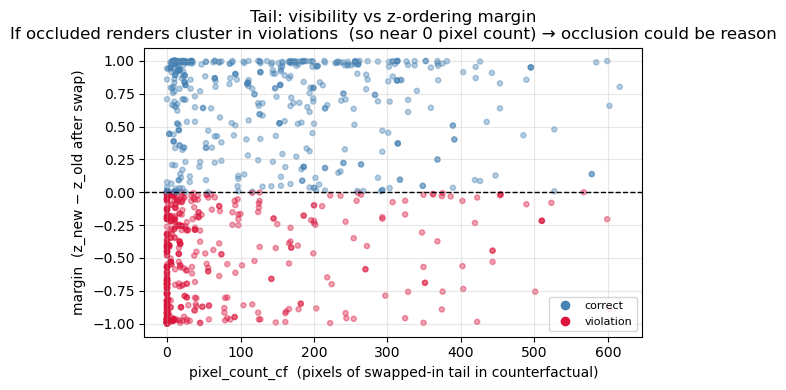

Saved fb_seg_pixel_vs_margin_tail.png


In [102]:
if all_z_rows_v2:
    from matplotlib.lines import Line2D
    tail_v2 = z_order_df_v2[z_order_df_v2['part'] == 'tail']
    colors  = tail_v2['ordering_correct'].map({True: 'steelblue', False: 'crimson'})

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(tail_v2['pixel_count_cf'], tail_v2['margin'],
               c=colors, s=14, alpha=0.4)
    ax.axhline(0, color='black', ls='--', lw=1)
    ax.set_xlabel('pixel_count_cf  (pixels of swapped-in tail in counterfactual)')
    ax.set_ylabel('margin  (z_new − z_old after swap)')
    ax.set_title('Tail: visibility vs z-ordering margin\n'
                 'If occluded renders cluster in violations  (so near 0 pixel count) → occlusion could be reason')
    ax.legend(handles=[
        Line2D([0],[0],marker='o',color='w',markerfacecolor='steelblue',ms=8,label='correct'),
        Line2D([0],[0],marker='o',color='w',markerfacecolor='crimson', ms=8,label='violation'),
    ], fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('fb_seg_pixel_vs_margin_tail.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_seg_pixel_vs_margin_tail.png')

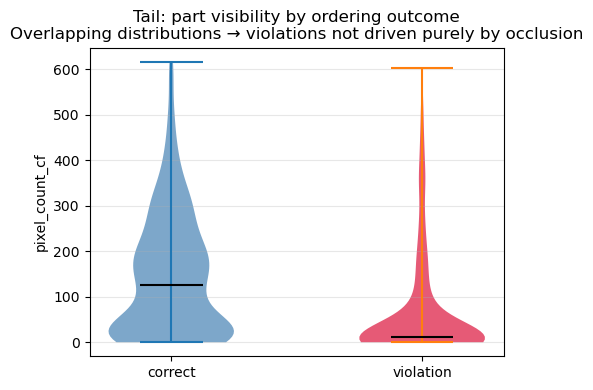

Mann-Whitney U (correct > violation in pixel_count):  U=186622  p=0.0000
  correct  median px: 126
  violation median px: 11
Saved fb_seg_violin_tail.png


In [103]:
if all_z_rows_v2:
    tail_v2 = z_order_df_v2[z_order_df_v2['part'] == 'tail'].copy()
    tail_v2['outcome'] = tail_v2['ordering_correct'].map({True: 'correct', False: 'violation'})

    fig, ax = plt.subplots(figsize=(5, 4))
    for i, (label, color) in enumerate([('correct','steelblue'),('violation','crimson')]):
        sub = tail_v2[tail_v2['outcome'] == label]['pixel_count_cf']
        parts = ax.violinplot(sub, positions=[i], showmedians=True, showextrema=True)
        for pc in parts['bodies']:
            pc.set_facecolor(color); pc.set_alpha(0.7)
        parts['cmedians'].set_color('black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['correct', 'violation'])
    ax.set_ylabel('pixel_count_cf')
    ax.set_title('Tail: part visibility by ordering outcome\n'
                 'Overlapping distributions → violations not driven purely by occlusion')
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('fb_seg_violin_tail.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Mann-Whitney U test
    from scipy.stats import mannwhitneyu
    grp_c = tail_v2[tail_v2['outcome']=='correct']['pixel_count_cf']
    grp_v = tail_v2[tail_v2['outcome']=='violation']['pixel_count_cf']
    u_stat, p_val = mannwhitneyu(grp_c, grp_v, alternative='greater')
    print(f'Mann-Whitney U (correct > violation in pixel_count):  U={u_stat:.0f}  p={p_val:.4f}')
    print(f'  correct  median px: {grp_c.median():.0f}')
    print(f'  violation median px: {grp_v.median():.0f}')
    print('Saved fb_seg_violin_tail.png')

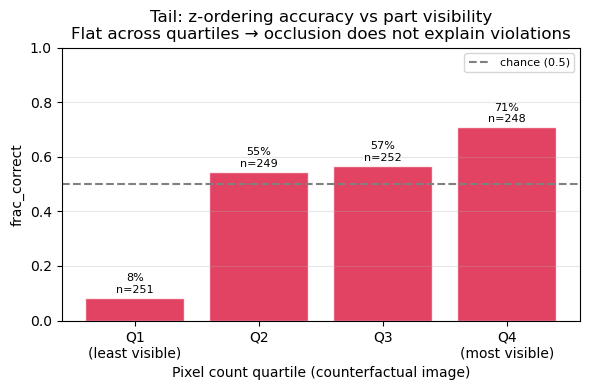

        px_quartile   n  frac_correct  med_px
Q1\n(least visible) 251      0.083665     0.0
                 Q2 249      0.546185    16.0
                 Q3 252      0.567460    96.5
 Q4\n(most visible) 248      0.709677   287.0
Saved fb_seg_quartile_frac_correct_tail.png


In [104]:
if all_z_rows_v2:
    tail_v2 = z_order_df_v2[z_order_df_v2['part'] == 'tail'].copy()
    tail_v2['px_quartile'] = pd.qcut(tail_v2['pixel_count_cf'], q=4,
                                     labels=['Q1\n(least visible)', 'Q2', 'Q3', 'Q4\n(most visible)'])
    q_summary = (tail_v2.groupby('px_quartile', observed=True)
                 .agg(n=('ordering_correct','size'),
                      frac_correct=('ordering_correct','mean'),
                      med_px=('pixel_count_cf','median'))
                 .reset_index())

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(q_summary['px_quartile'].astype(str), q_summary['frac_correct'],
           color=PART_COLORS['tail'], alpha=0.8, edgecolor='white')
    ax.axhline(0.5, color='gray', ls='--', lw=1.5, label='chance (0.5)')
    for _, row in q_summary.iterrows():
        ax.text(str(row['px_quartile']), row['frac_correct'] + 0.01,
                f'{row["frac_correct"]:.0%}\nn={row["n"]}', ha='center', va='bottom', fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Pixel count quartile (counterfactual image)')
    ax.set_ylabel('frac_correct')
    ax.set_title('Tail: z-ordering accuracy vs part visibility\n'
                 'Flat across quartiles → occlusion does not explain violations')
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('fb_seg_quartile_frac_correct_tail.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(q_summary.to_string(index=False))
    print('Saved fb_seg_quartile_frac_correct_tail.png')

=== Before filter  (n=1023) ===


,part,n,frac_correct,frac_violations,mean_margin
0,tail,1000,0.476000,0.524000,0.058219
1,beak,23,0.608696,0.391304,0.118730



=== After filter  pixel_count_cf >= 50  (n=469) ===


,part,n,frac_correct,frac_violations,mean_margin
0,tail,454,0.676211,0.323789,0.314729
1,beak,15,0.733333,0.266667,0.324539


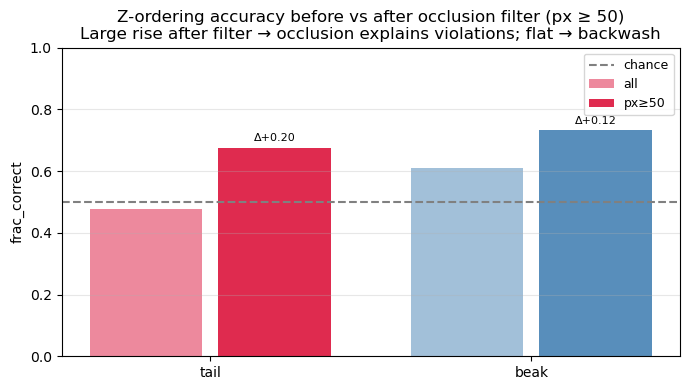

Saved fb_seg_filter_comparison.png


In [93]:
if all_z_rows_v2:
    MIN_PART_PIXELS = 50   # tune this — images where swapped-in part occupies <50 px

    def make_part_summary(df):
        return (df.groupby('part', as_index=False)
                .agg(n=('ordering_correct','size'),
                     frac_correct=('ordering_correct','mean'),
                     frac_violations=('ordering_correct', lambda x: 1 - x.mean()),
                     mean_margin=('margin','mean'))
                .sort_values('frac_violations', ascending=False)
                .reset_index(drop=True))

    summary_all      = make_part_summary(z_order_df_v2)
    summary_filtered = make_part_summary(
        z_order_df_v2[z_order_df_v2['pixel_count_cf'] >= MIN_PART_PIXELS])

    print(f'=== Before filter  (n={len(z_order_df_v2)}) ===')
    display(summary_all[['part','n','frac_correct','frac_violations','mean_margin']])
    print(f'\n=== After filter  pixel_count_cf >= {MIN_PART_PIXELS}  '
          f'(n={len(z_order_df_v2[z_order_df_v2["pixel_count_cf"]>=MIN_PART_PIXELS])}) ===')
    display(summary_filtered[['part','n','frac_correct','frac_violations','mean_margin']])

    # Visual comparison
    merged = summary_all[['part','frac_correct']].merge(
        summary_filtered[['part','frac_correct']], on='part', suffixes=('_all','_filtered'))
    merged['delta'] = merged['frac_correct_filtered'] - merged['frac_correct_all']

    fig, ax = plt.subplots(figsize=(7, 4))
    x = range(len(merged))
    ax.bar([i - 0.2 for i in x], merged['frac_correct_all'],     width=0.35,
           color=[PART_COLORS[p] for p in merged['part']], alpha=0.5, label='all')
    ax.bar([i + 0.2 for i in x], merged['frac_correct_filtered'], width=0.35,
           color=[PART_COLORS[p] for p in merged['part']], alpha=0.9, label=f'px≥{MIN_PART_PIXELS}')
    ax.axhline(0.5, color='gray', ls='--', lw=1.5, label='chance')
    ax.set_xticks(list(x)); ax.set_xticklabels(merged['part'])
    ax.set_ylabel('frac_correct')
    ax.set_ylim(0, 1)
    ax.set_title(f'Z-ordering accuracy before vs after occlusion filter (px ≥ {MIN_PART_PIXELS})\n'
                 'Large rise after filter → occlusion explains violations; flat → backwash')
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    for i, row in merged.iterrows():
        ax.text(i + 0.2, row['frac_correct_filtered'] + 0.02,
                f'Δ{row["delta"]:+.2f}', ha='center', fontsize=8)
    plt.tight_layout()
    plt.savefig('fb_seg_filter_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_seg_filter_comparison.png')